In [71]:
import pandas as pd
import duckdb 
# Загружаем все таблицы
clicks = pd.read_csv('clicks.csv')
data_dictionary = pd.read_csv('data_dictionary.csv')
experiment_assignments = pd.read_csv('experiment_assignments.csv')
impressions = pd.read_csv('impressions.csv')
orders = pd.read_csv('orders.csv')
premium_subscriptions = pd.read_csv('premium_subscriptions.csv')
products = pd.read_csv('products.csv')
sellers = pd.read_csv('sellers.csv')
sessions = pd.read_csv('sessions.csv')
support_tickets = pd.read_csv('support_tickets.csv')
users = pd.read_csv('users.csv')
con = duckdb.connect()

duckdb.register('clicks', clicks)
duckdb.register('data_dictionary', data_dictionary)
duckdb.register('experiment_assignments', experiment_assignments)
duckdb.register('impressions', impressions)
duckdb.register('orders', orders)
duckdb.register('premium_subscriptions', premium_subscriptions)
duckdb.register('products', products)
duckdb.register('sellers', sellers)
duckdb.register('sessions', sessions)
duckdb.register('support_tickets', support_tickets)
duckdb.register('users', users)

#### Посмотрим на общую информацию по таблицам 

In [72]:
tables = {
    'clicks': pd.read_csv('clicks.csv'),
    'data_dictionary': pd.read_csv('data_dictionary.csv'),
    'experiment_assignments': pd.read_csv('experiment_assignments.csv'),
    'impressions': pd.read_csv('impressions.csv'),
    'orders': pd.read_csv('orders.csv'),
    'premium_subscriptions': pd.read_csv('premium_subscriptions.csv'),
    'products': pd.read_csv('products.csv'),
    'sellers': pd.read_csv('sellers.csv'),
    'sessions': pd.read_csv('sessions.csv'),
    'support_tickets': pd.read_csv('support_tickets.csv'),
    'users': pd.read_csv('users.csv')
}

for table_name, df in tables.items():
    print(f"\n{'='*80}")
    print(f"таблица: {table_name}")
    print(f"{'='*80}")
    df.info()
    print(f"\n")


таблица: clicks
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91266 entries, 0 to 91265
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   click_id       91266 non-null  object
 1   impression_id  91266 non-null  object
 2   session_id     91266 non-null  object
 3   user_id        91266 non-null  object
 4   event_time     91266 non-null  object
 5   product_id     91266 non-null  object
 6   position       91266 non-null  int64 
dtypes: int64(1), object(6)
memory usage: 4.9+ MB



таблица: data_dictionary
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   table        23 non-null     object
 1   field        23 non-null     object
 2   type         23 non-null     object
 3   description  23 non-null     object
dtypes: object(4)
memory usage: 868.0+ bytes



таблица: exper

In [73]:
result_df = duckdb.sql("""
    SELECT 
        COUNT(*) AS total_rows,                           
        COUNT(delivery_fee_rub) AS delivery_fee_non_null, 
        COUNT(return_date) AS return_date_non_null,       
        SUM(CASE WHEN delivery_fee_rub IS NULL THEN 1 ELSE 0 END) AS delivery_fee_null_count, 
        SUM(CASE WHEN return_date IS NULL OR return_date = '' THEN 1 ELSE 0 END) AS return_date_null_count        
    FROM orders;
""").df()

print(result_df)

   total_rows  delivery_fee_non_null  return_date_non_null  \
0        7407                   7104                   462   

   delivery_fee_null_count  return_date_null_count  
0                 303.0000               6945.0000  


### 1.1 Пропуски в данных

Прошли по всем 11 таблицам через `df.info()`. Пропуски обнаружены 
только в таблице `orders`:

| Колонка | Non-null | Всего строк | Null, % |
|---|---|---|---|
| `delivery_fee_rub` | 7 104 | 7 407 | 4.1% |
| `return_date` | 462 | 7 407 | 93.8% |

В остальных 10 таблицах пропусков нет.

**Дальнейшие шаги:**
-  `return_date` - проверить связь с `is_returned` 
-  `delivery_fee_rub` - проверить распределение и выбрать способ заполнения 

In [74]:
result_df = duckdb.sql("""
   SELECT
    is_returned,
    COUNT(*) AS orders,
    SUM(
        CASE
            WHEN return_date IS NULL
              OR TRIM(return_date) = ''
            THEN 1
            ELSE 0
        END
    ) AS null_return_date
FROM orders
GROUP BY is_returned
ORDER BY is_returned;
""").df()

print(result_df)

   is_returned  orders  null_return_date
0            0    6945         6945.0000
1            1     462            0.0000



> Для return_date видим, что null-значения соответствуют невозвращенным товарам, так что их заполнять или удалять не нужно.
>
> Можем для удобства заменить их на 0, но это необязательно


#### Более подробно рассмотрим количество заказов с незаполненной стоимостью доставки

In [75]:
result_df = duckdb.sql("""
   SELECT
    payment_type,
    is_returned,
    COUNT(*) AS orders,
    SUM(
        CASE
            WHEN delivery_fee_rub IS NULL THEN 1
            ELSE 0
        END
    ) AS null_delivery_fee
FROM orders
GROUP BY
    payment_type,
    is_returned
ORDER BY null_delivery_fee DESC;
""").df()

print(result_df)

       payment_type  is_returned  orders  null_delivery_fee
0         bank_card            0    3076           130.0000
1         ozon_card            0    1863            80.0000
2           sberpay            0     896            34.0000
3       installment            0     621            23.0000
4  cash_on_delivery            0     489            16.0000
5         bank_card            1     207             8.0000
6         ozon_card            1     130             6.0000
7           sberpay            1      59             5.0000
8  cash_on_delivery            1      36             1.0000
9       installment            1      30             0.0000


#### Проверим, не являются ли null-значения в delivery_fee_rub просто нулевыми (бесплатная доставка)

In [76]:
result_df = duckdb.sql("""
   SELECT
    MIN(delivery_fee_rub) AS min_delivery,
    MAX(delivery_fee_rub) AS max_delivery,
    AVG(delivery_fee_rub) AS avg_delivery,
    PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY delivery_fee_rub) AS median_delivery
FROM orders
WHERE delivery_fee_rub IS NOT NULL;
""").df()

print(result_df)

   min_delivery  max_delivery  avg_delivery  median_delivery
0        0.0000      481.0000      150.4569         166.0000


### 1.2 Заполнение `delivery_fee_rub`

Проверили распределение стоимости доставки среди непустых значений:

| Метрика | Значение |
|---|---|
| Min | 0 ₽ |
| Median | 166 ₽ |
| Mean | 150.5 ₽ |
| Max | 481 ₽ |

Нулевые значения встречаются - это бесплатная доставка. Значит, 
`NULL` **нельзя** заполнять нулём: это смешало бы два разных 
сценария (нет данных vs бесплатная доставка).

Поэтому заполняем пропуски **медианой (166 ₽)**.

Медиана устойчива к выбросам и точнее отражает типичную 
стоимость доставки, чем среднее.

---

In [77]:
#Сразу создадим новую таблицу с заполненными медианой значениями 
duckdb.sql("""
CREATE OR REPLACE TABLE orders_new AS
WITH median_calc AS (
    SELECT PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY delivery_fee_rub) AS median_delivery_fee
    FROM orders
    WHERE delivery_fee_rub IS NOT NULL
)
SELECT 
    order_id,
    user_id,
    session_id,
    click_id,
    order_date,
    product_id,
    category,
    gmv_rub,
    discount_rub,
    COALESCE(delivery_fee_rub, (SELECT median_delivery_fee FROM median_calc)) AS delivery_fee_rub,
    payment_type,
    is_returned,
    return_date,
    gross_margin_rub
FROM orders;
""")


result_df = duckdb.sql("SELECT * FROM orders_new").df()
print(result_df)

           order_id   user_id   session_id        click_id  order_date  \
0     ord_000000001  u_000007  ss_00000016  clk_0000000007  2026-07-02   
1     ord_000000002  u_000020  ss_00000070  clk_0000000059  2026-07-14   
2     ord_000000003  u_000024  ss_00000081  clk_0000000064  2026-07-02   
3     ord_000000004  u_000028  ss_00000097  clk_0000000068  2026-07-15   
4     ord_000000005  u_000037  ss_00000131  clk_0000000079  2026-07-10   
...             ...       ...          ...             ...         ...   
7402  ord_000007403  u_049984  ss_00164684  clk_0000091242  2026-07-24   
7403  ord_000007404  u_049987  ss_00164693  clk_0000091244  2026-07-18   
7404  ord_000007405  u_049994  ss_00164718  clk_0000091252  2026-07-01   
7405  ord_000007406  u_049999  ss_00164730  clk_0000091264  2026-07-14   
7406  ord_000007407  u_049999  ss_00164734  clk_0000091266  2026-07-10   

     product_id     category  gmv_rub  discount_rub  delivery_fee_rub  \
0       p_01555      Fashion     4374 

#### Проверим на дубликаты

In [78]:
tables = {
    'users': pd.read_csv('users.csv'),
    'experiment_assignments': pd.read_csv('experiment_assignments.csv'),
    'sessions': pd.read_csv('sessions.csv'),
    'impressions': pd.read_csv('impressions.csv'),
    'clicks': pd.read_csv('clicks.csv'),
    'orders': pd.read_csv('orders.csv'),
    'products': pd.read_csv('products.csv'),
    'sellers': pd.read_csv('sellers.csv'),
    'premium_subscriptions': pd.read_csv('premium_subscriptions.csv'),
    'support_tickets': pd.read_csv('support_tickets.csv')
}

#Функция для анализа дубликатов
def analyze_duplicates(df, table_name):
    results = []
    
    #Полные дубликаты
    full_dups = df.duplicated().sum()
    
    #Дубликаты по первичному ключу 
    pk_columns = {
        'users': 'user_id',
        'experiment_assignments': 'assignment_id',
        'sessions': 'session_id',
        'impressions': 'impression_id',
        'clicks': 'click_id',
        'orders': 'order_id',
        'products': 'product_id',
        'sellers': 'seller_id',
        'premium_subscriptions': 'user_id',
        'support_tickets': 'ticket_id'
    }
    
    pk = pk_columns.get(table_name)
    pk_dups = 0
    pk_sample = None
    
    if pk and pk in df.columns:
        pk_dups = df[pk].duplicated().sum()
        if pk_dups > 0:
            pk_sample = df[df[pk].duplicated(keep=False)][[pk]].head(5)
    
    
    total_rows = len(df)
    full_dup_percentage = round(full_dups * 100 / total_rows, 2) if total_rows > 0 else 0
    pk_dup_percentage = round(pk_dups * 100 / total_rows, 2) if total_rows > 0 else 0
    
    results.append({
        'table_name': table_name,
        'total_rows': total_rows,
        'full_duplicates': full_dups,
        'full_dup_percentage': full_dup_percentage,
        'pk_column': pk,
        'pk_duplicates': pk_dups,
        'pk_dup_percentage': pk_dup_percentage,
        'pk_sample': pk_sample
    })
    
    return results[0]

#Анализируем все таблицы
all_results = []
for table_name, df in tables.items():
    result = analyze_duplicates(df, table_name)
    all_results.append(result)

#Создаем отчет
report_df = pd.DataFrame(all_results)
report_df = report_df[['table_name', 'total_rows', 'full_duplicates', 'full_dup_percentage', 
                       'pk_column', 'pk_duplicates', 'pk_dup_percentage']]

print("дубликаты:")
print("=" * 80)
print(report_df.to_string(index=False))


дубликаты:
            table_name  total_rows  full_duplicates  full_dup_percentage     pk_column  pk_duplicates  pk_dup_percentage
                 users       50000                0               0.0000       user_id              0             0.0000
experiment_assignments       50300                0               0.0000 assignment_id              0             0.0000
              sessions      164739                0               0.0000    session_id              0             0.0000
           impressions     1066434                0               0.0000 impression_id              0             0.0000
                clicks       91266                0               0.0000      click_id              0             0.0000
                orders        7407                0               0.0000      order_id              0             0.0000
              products        4500                0               0.0000    product_id              0             0.0000
               seller

### 1.3 Проверка дубликатов

Проверили полные дубли строк и дубликаты по первичным ключам 
во всех 10 таблицах. **Дубликатов не обнаружено** ни в одной из таблиц.

---
#### Проверим данные на аномалии

> Диапазон временных значений должен лежать в 30-дневном периоде, так что по релевантным для тестирования столбцам проверим попадание
в диапазон значений (например дата регистрации продавца joined_date из таблицы sellers нам не особо интересна)

In [79]:
result_df = duckdb.sql("""
    SELECT 'sessions' AS table_name,
       MIN(session_date::DATE) AS min_date,
       MAX(session_date::DATE) AS max_date,
       COUNT(*) AS row_count
FROM sessions

UNION ALL

SELECT 'impressions',
       MIN(event_time::DATE),
       MAX(event_time::DATE),
       COUNT(*)
FROM impressions

UNION ALL

SELECT 'clicks',
       MIN(event_time::DATE),
       MAX(event_time::DATE),
       COUNT(*)
FROM clicks

UNION ALL

SELECT 'orders',
       MIN(order_date::DATE),
       MAX(order_date::DATE),
       COUNT(*)
FROM orders

UNION ALL

SELECT 'experiment_assignments',
       MIN(assignment_date::DATE),
       MAX(assignment_date::DATE),
       COUNT(*)
FROM experiment_assignments;
""").df()

print(result_df)

               table_name   min_date   max_date  row_count
0                sessions 2026-07-01 2026-07-30     164739
1             impressions 2026-07-01 2026-07-30    1066434
2                  clicks 2026-07-01 2026-07-30      91266
3                  orders 2026-07-01 2026-07-30       7407
4  experiment_assignments 2026-07-01 2026-07-06      50300


### 1.4 Проверка временных диапазонов

Эксперимент проходит с 01.07.2026 по 30.07.2026. Проверили, что 
все события в релевантных таблицах попадают в этот интервал.

**В периметре проверки:**

| Таблица | Столбец | Мин. дата | Макс. дата | 
|---|---|---|---|
| `sessions` | `session_date` | 2026-07-01 | 2026-07-30 | 
| `impressions` | `event_time` | 2026-07-01 | 2026-07-30 | 
| `clicks` | `event_time` | 2026-07-01 | 2026-07-30 | 
| `orders` | `order_date` | 2026-07-01 | 2026-07-30 | 
| `experiment_assignments` | `assignment_date` | 2026-07-01 | 2026-07-06 | 

**Вне периметра проверки:**

- `sellers.joined_date` - дата регистрации продавца может быть 
  задолго до эксперимента, не влияет на анализ.
- `users.registration_date` - аналогично, регистрация предшествует 
  эксперименту.
- `premium_subscriptions.premium_start_date` - может выходить 
  за пределы окна, если подписка началась до старта теста.
- `products.created_date` - дата создания товара не имеет значения 
  для анализа поведения.

**Вывод:** все события релевантных таблиц попадают в 30-дневное 
окно. Аномалий по датам не обнаружено.

---

#### Базовая статистика по ключевым метрикам

In [80]:
result_df = duckdb.sql("""
    SELECT 
    MIN(gmv_rub) AS min_gmv,
    PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY gmv_rub) AS p25_gmv,
    PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY gmv_rub) AS median_gmv,
    PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY gmv_rub) AS p75_gmv,
    MAX(gmv_rub) AS max_gmv,
    AVG(gmv_rub) AS avg_gmv
FROM orders
""").df()

print(result_df)

   min_gmv  p25_gmv  median_gmv   p75_gmv  max_gmv   avg_gmv
0       84 615.0000   1165.0000 2140.5000    21926 1676.4642


#### Проверка отрицательных значений в заказах (должно быть 0)

In [81]:
result_df = duckdb.sql("""
    SELECT 
    SUM(CASE WHEN gmv_rub < 0 THEN 1 ELSE 0 END) AS negative_gmv_orders,
    SUM(CASE WHEN discount_rub < 0 THEN 1 ELSE 0 END) AS negative_discount_orders,
    SUM(CASE WHEN delivery_fee_rub < 0 THEN 1 ELSE 0 END) AS negative_delivery_orders
FROM orders;
""").df()
print(result_df)

   negative_gmv_orders  negative_discount_orders  negative_delivery_orders
0               0.0000                    0.0000                    0.0000


#### Проверка маржинальности (не должна быть > 1 или < 0)

In [82]:
result_df = duckdb.sql("""
    SELECT 
    SUM(CASE WHEN gross_margin_rate < 0 OR gross_margin_rate > 1 THEN 1 ELSE 0 END) AS invalid_margin_products
FROM products;


""").df()
print(result_df)

   invalid_margin_products
0                   0.0000


#### Проверка аномально коротких или длинных сессий

In [83]:
result_df = duckdb.sql("""
    SELECT 
    MIN(session_duration_sec) AS min_duration,
    PERCENTILE_CONT(0.01) WITHIN GROUP (ORDER BY session_duration_sec) AS p01_duration,
    PERCENTILE_CONT(0.99) WITHIN GROUP (ORDER BY session_duration_sec) AS p99_duration,
    MAX(session_duration_sec) AS max_duration
FROM sessions;


""").df()
print(result_df)

   min_duration  p01_duration  p99_duration  max_duration
0            12       49.0000     1246.0000          7200


---
> Видим, что только 1% сессий короче 49 секунд, 99% сессий длятся до 1246 сек,
> есть экстремально длинные сессии, которые выбиваются из общего паттерна (7200 сек)
>
> Посмотрим количество сессий в каждом диапазоне

In [84]:
result_df = duckdb.sql("""
    SELECT
    CASE
        WHEN session_duration_sec <= 300 THEN '0-5 мин'
        WHEN session_duration_sec <= 600 THEN '5-10 мин'
        WHEN session_duration_sec <= 1800 THEN '10-30 мин'
        WHEN session_duration_sec <= 3600 THEN '30-60 мин'
        ELSE '> 60 мин'
    END AS duration_range,
    COUNT(*) AS sessions_count,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS percent
FROM sessions
GROUP BY duration_range
ORDER BY MIN(session_duration_sec);


""").df()
print(result_df)

  duration_range  sessions_count  percent
0        0-5 мин          108556  65.9000
1       5-10 мин           42826  26.0000
2      10-30 мин           12826   7.7900
3      30-60 мин             494   0.3000
4       > 60 мин              37   0.0200


### 1.5 Аномальные длительности сессий

Проверили распределение `session_duration_sec`:

| Метрика | Значение |
|---|---|
| Min | 12 сек |
| p01 | 49 сек |
| p99 | 1 246 сек |
| Max | 7 200 сек |

**Наблюдения:**

- 1% сессий короче 49 секунд - они не несут аналитической ценности, 
  но их доля незначительна.
- 99% сессий укладываются в 1 246 секунд (~20 минут).
- Максимум - 7 200 секунд (2 часа) - это аномально длинные сессии, 
  выбивающиеся из общего паттерна.

Распределение по диапазонам:

| Диапазон | Сессий | Доля |
|---|---|---|
| 0–5 мин | 108 556 | 65.9% |
| 5–10 мин | 42 826 | 26.0% |
| 10–30 мин | 12 826 | 7.8% |
| 30–60 мин | 494 | 0.3% |
| > 60 мин | 37 | 0.02% |

---

### 1.6 Отсечение выбросов по `session_duration_sec`

Аномально длинные сессии (> p99 = 1 246 сек) могут:

- искажать среднее значение;
- быть следствием технических ошибок (сессия не завершилась);
- не отражать реальное поведение пользователя.

> **Решение:** отсекаем сессии длительностью выше p99 (1 246 сек).

**Обоснование:** порог p99 стандартно используется для удаления 
выбросов в скошенных распределениях. Отсечение по p99 удаляет 
~1% данных - потерь для анализа почти нет, а аномалии уходят.

Итоговая выборка: `sessions_new` (163 093 сессии из 164 739, 
удалено 1 646 = 1%).

In [85]:
#Создаем таблицу 
duckdb.sql("""
CREATE OR REPLACE TABLE sessions_new AS
WITH percentile_calc AS (
    SELECT 
        PERCENTILE_CONT(0.99) WITHIN GROUP (ORDER BY session_duration_sec) AS p99_duration
    FROM sessions
    WHERE session_duration_sec IS NOT NULL
)
SELECT 
    session_id,
    user_id,
    session_date,
    device,
    region,
    experiment_group,
    session_duration_sec,
    page_views,
    entry_point
FROM sessions
WHERE session_duration_sec <= (SELECT p99_duration FROM percentile_calc);
""")


result_df = duckdb.sql("SELECT * FROM sessions_new").df()
print(result_df)

         session_id   user_id session_date   device          region  \
0       ss_00000001  u_000001   2026-07-27  android           Volga   
1       ss_00000002  u_000001   2026-07-24  android           Volga   
2       ss_00000003  u_000002   2026-07-17  android  Central Russia   
3       ss_00000004  u_000003   2026-07-14      web          Moscow   
4       ss_00000005  u_000003   2026-07-16      web          Moscow   
...             ...       ...          ...      ...             ...   
163088  ss_00164735  u_049999   2026-07-21      web          Moscow   
163089  ss_00164736  u_049999   2026-07-19      web          Moscow   
163090  ss_00164737  u_050000   2026-07-07      ios           Volga   
163091  ss_00164738  u_050000   2026-07-12      ios           Volga   
163092  ss_00164739  u_050000   2026-07-25      ios           Volga   

       experiment_group  session_duration_sec  page_views   entry_point  
0               control                   117           5        search  

#### Проверка кликов без соответствующего показа

In [86]:
result_df = duckdb.sql("""
    SELECT 
    COUNT(*) AS clicks_without_impressions
FROM clicks c
LEFT JOIN impressions i ON c.impression_id = i.impression_id
WHERE i.impression_id IS NULL;



""").df()
print(result_df)

   clicks_without_impressions
0                           0


#### Проверка заказов без клика

In [87]:
result_df = duckdb.sql("""
    SELECT 
    COUNT(*) AS orders_without_click
FROM orders o
LEFT JOIN clicks c ON o.click_id = c.click_id
WHERE c.click_id IS NULL;


""").df()
print(result_df)

   orders_without_click
0                     0


#### Проверка пользователей с активной подпиской, но помеченных как is_premium = 0 в users
> по датам окончание подписки проверить не можем, поэтому будем считать что активна имеется в виду на протяжении эксперимента 

In [88]:
result_df = duckdb.sql("""
    SELECT 
    COUNT(*) AS inconsistent_premium
FROM premium_subscriptions ps
JOIN users u ON ps.user_id = u.user_id
WHERE ps.premium_status = 'active' 
  AND u.is_premium = 0


""").df()
print(result_df)

   inconsistent_premium
0                   821


In [89]:
#Если исключить пробные подписки с расчетом, что они закончились 
result_df = duckdb.sql("""
    SELECT 
    COUNT(*) AS inconsistent_premium
FROM premium_subscriptions ps
JOIN users u ON ps.user_id = u.user_id
WHERE ps.premium_status = 'active' and ps.is_trial = '0'
  AND u.is_premium = 0
""").df()
print(result_df)

   inconsistent_premium
0                   358


In [90]:
# Процент 
result_df = duckdb.sql("""
    SELECT 
    COUNT(*) AS inconsistent_count,
    (SELECT COUNT(*) FROM premium_subscriptions WHERE premium_status = 'active') AS total_active,
    ROUND(
        100.0 * COUNT(*) / (SELECT COUNT(*) FROM premium_subscriptions WHERE premium_status = 'active'), 
        2
    ) AS inconsistent_percent
FROM premium_subscriptions ps
JOIN users u ON ps.user_id = u.user_id
WHERE ps.premium_status = 'active' 
  AND u.is_premium = 0;
""").df()
print(result_df)

   inconsistent_count  total_active  inconsistent_percent
0                 821          8600                9.5500


### 1.7 Расхождение `is_premium` и `premium_status`

Проверили пользователей с активной подпиской в `premium_subscriptions`, 
у которых в `users.is_premium = 0`:

| Метрика | Значение |
|---|---|
| Активных подписок | 8 600 |
| Расхождений с `users.is_premium` | 821 |
| Доля расхождений | **9.55%** |

**Проблема:** около 10% активных подписчиков не помечены как premium 
в основной таблице `users`. Такой процент слишком высок, чтобы 
списать его на единичные технические сбои.

**Гипотеза:** вероятная причина - некорректная работа сервиса, 
синхронизирующего статус подписки с полем `is_premium` в `users`. 
Флаг не обновляется при продлении или активации подписки.

> **Рекомендация:** настроить автоматическое обновление 
> `users.is_premium` при изменении `premium_subscriptions.premium_status`.

**Влияние на анализ:** такие пользователи попадают в контрольную 
или тестовую группу с некорректной premium-разметкой, что может 
искажать метрику premium-конверсии. До исправления сервиса 
интерпретировать эту метрику следует с осторожностью

---

#### Проверим корректность распределения между группами 

In [91]:
result_df = duckdb.sql("""
    WITH test_users AS (
    SELECT DISTINCT user_id 
    FROM experiment_assignments 
    WHERE experiment_group = 'test'
),
control_users AS (
    SELECT DISTINCT user_id 
    FROM experiment_assignments 
    WHERE experiment_group = 'control'
)
SELECT 
    (SELECT COUNT(*) FROM test_users) AS test_users_count,
    (SELECT COUNT(*) FROM control_users) AS control_users_count,
    COUNT(*) AS users_in_both_groups
FROM test_users t
INNER JOIN control_users c ON t.user_id = c.user_id;
""").df()
print(result_df)

   test_users_count  control_users_count  users_in_both_groups
0             25326                24974                   300


--- 
####  Видим, что 300 человек попадают в обе выборки, поэтому такие данные необходимо исключить, чтобы результаты A/B теста были корректными
> Создаем таблицу users_new и experiment_assignments_new без таких пользователей

In [92]:
duckdb.sql("""
CREATE OR REPLACE TABLE users_new AS
WITH users_in_both AS (
    SELECT user_id
    FROM experiment_assignments
    WHERE experiment_group IN ('test', 'control')
    GROUP BY user_id
    HAVING COUNT(DISTINCT experiment_group) = 2
)
SELECT 
    user_id,
    registration_date,
    region,
    device,
    age_group,
    traffic_source,
    is_premium,
    is_bot_candidate
FROM users
WHERE user_id NOT IN (SELECT user_id FROM users_in_both);
""")

duckdb.sql("""
CREATE OR REPLACE TABLE experiment_assignments_new AS
WITH users_in_both AS (
    SELECT user_id
    FROM experiment_assignments
    WHERE experiment_group IN ('test', 'control')
    GROUP BY user_id
    HAVING COUNT(DISTINCT experiment_group) = 2
)
SELECT 
    assignment_id,
    user_id,
    experiment_name,
    experiment_group,
    assignment_date,
    assignment_source
FROM experiment_assignments
WHERE user_id NOT IN (SELECT user_id FROM users_in_both);
""")

#Проверяем результат
print("=== users_new ===")
print(duckdb.sql("SELECT COUNT(*) FROM users_new").df())
print("\n=== experiment_assignments_new ===")
print(duckdb.sql("SELECT COUNT(*) FROM experiment_assignments_new").df())

#Проверяем, что пользователей в обеих группах больше нет
print("\n=== Проверка пересечений ===")
result_check = duckdb.sql("""
WITH test_users AS (
    SELECT DISTINCT user_id 
    FROM experiment_assignments_new 
    WHERE experiment_group = 'test'
),
control_users AS (
    SELECT DISTINCT user_id 
    FROM experiment_assignments_new 
    WHERE experiment_group = 'control'
)
SELECT 
    (SELECT COUNT(*) FROM test_users) AS test_users_count,
    (SELECT COUNT(*) FROM control_users) AS control_users_count,
    COUNT(*) AS users_in_both_groups
FROM test_users t
INNER JOIN control_users c ON t.user_id = c.user_id;
""").df()
print(result_check)

=== users_new ===
   count_star()
0         49700

=== experiment_assignments_new ===
   count_star()
0         49700

=== Проверка пересечений ===
   test_users_count  control_users_count  users_in_both_groups
0             25026                24674                     0


#### Проверим, что распределение 50/50

In [93]:
result_df = duckdb.sql("""
SELECT
    experiment_group,
    COUNT(DISTINCT user_id) AS users,
    ROUND(
        100.0 * COUNT(DISTINCT user_id)
        / SUM(COUNT(DISTINCT user_id)) OVER (),
        2
    ) AS share_pct
FROM experiment_assignments_new
WHERE experiment_name = 'ai_recommendations_homepage'
GROUP BY experiment_group;
""").df()
print(result_df)

  experiment_group  users  share_pct
0          control  24674    49.6500
1             test  25026    50.3500


#### Расссмотрим сруктуру аудитории. Количество пользователей

In [94]:
result_df = duckdb.sql("""
    SELECT
        COUNT(*) AS users_total,
        COUNT(DISTINCT user_id) AS unique_users
    FROM users_new;
""").df()
print(result_df)

   users_total  unique_users
0        49700         49700


#### Распределение пользователей по возрастным группам

In [95]:
result_df = duckdb.sql("""
    SELECT
    age_group,
    COUNT(*) AS users,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS share_pct
FROM users_new
GROUP BY age_group
ORDER BY users DESC
""").df()
print(result_df)

  age_group  users  share_pct
0     25-34  16660    33.5200
1     35-44  12572    25.3000
2     18-24   8974    18.0600
3     45-54   7481    15.0500
4       55+   4013     8.0700


#### Распределение пользователей по регионам

In [96]:
result_df = duckdb.sql("""
   SELECT
    region,
    COUNT(*) AS users,
    ROUND(
        100.0 * COUNT(*) / SUM(COUNT(*)) OVER (),
        2
    ) AS share_pct
FROM users_new
GROUP BY region
ORDER BY users DESC;
""").df()
print(result_df)

             region  users  share_pct
0    Central Russia  10892    21.9200
1            Moscow   8915    17.9400
2             Volga   8430    16.9600
3           Siberia   5960    11.9900
4              Ural   5050    10.1600
5             South   4558     9.1700
6  Saint Petersburg   4445     8.9400
7          Far East   1450     2.9200


#### Распределение пользователей по premium подписке (процент от количества пользователей) и по возрасту 

In [97]:
 result_dt = duckdb.sql("""
   SELECT
    is_premium,
    COUNT(*) AS users,
    ROUND(
        100.0 * COUNT(*) / SUM(COUNT(*)) OVER (),
        2
    ) AS share_pct
FROM users_new
GROUP BY is_premium
ORDER BY is_premium DESC;
""").df()
print(result_dt)

result_df = duckdb.sql("""
   SELECT
    age_group,
    COUNT(*) AS users,
    SUM(is_premium) AS premium_users,
    ROUND(
        100.0 * SUM(is_premium) / COUNT(*),
        2
    ) AS premium_share_pct
FROM users_new
GROUP BY age_group
ORDER BY users DESC;
""").df()
print(result_df)

   is_premium  users  share_pct
0           1   8209    16.5200
1           0  41491    83.4800
  age_group  users  premium_users  premium_share_pct
0     25-34  16660      2793.0000            16.7600
1     35-44  12572      1997.0000            15.8800
2     18-24   8974      1499.0000            16.7000
3     45-54   7481      1283.0000            17.1500
4       55+   4013       637.0000            15.8700


#### Распределение пользователей по ботам

In [98]:
result_df = duckdb.sql("""
   SELECT
    is_bot_candidate,
    COUNT(*) AS users,
    ROUND(
        100.0 * COUNT(*) / SUM(COUNT(*)) OVER (),
        2
    ) AS share_pct
FROM users_new
GROUP BY is_bot_candidate
ORDER BY is_bot_candidate DESC;
""").df()
print(result_df)

   is_bot_candidate  users  share_pct
0                 1    399     0.8000
1                 0  49301    99.2000


> Видим, что ботов меньше процента, но для чистоты эксперимента их нужно будет исключить

> обновим таблицу users_new

In [99]:
duckdb.sql("""
CREATE OR REPLACE TABLE users_new AS
WITH users_in_both AS (
    SELECT user_id
    FROM experiment_assignments
    WHERE experiment_group IN ('test', 'control')
    GROUP BY user_id
    HAVING COUNT(DISTINCT experiment_group) = 2
)
SELECT 
    user_id,
    registration_date,
    region,
    device,
    age_group,
    traffic_source,
    is_premium,
    is_bot_candidate
FROM users
WHERE user_id NOT IN (SELECT user_id FROM users_in_both)
AND is_bot_candidate = 0;
""")

#### Распределение устройств в пользовательских сессиях

In [100]:
result_df = duckdb.sql("""
   SELECT
    device,
    COUNT(*) AS sessions,
    COUNT(DISTINCT user_id) AS users,
    ROUND(
        1.0 * COUNT(*) / COUNT(DISTINCT user_id),
        2
    ) AS sessions_per_user
FROM sessions_new
GROUP BY device
ORDER BY sessions DESC;
""").df()
print(result_df)

    device  sessions  users  sessions_per_user
0  android     94021  28877             3.2600
1      ios     43835  13466             3.2600
2      web     25237   7626             3.3100


### 1.8 Распределение устройств

Проверили, как устройства распределены среди сессий пользователей:

| Устройство | Сессий | Пользователей | Сессий / пользователя |
|---|---|---|---|
| android | 94 021 | 28 877 | 3.26 |
| ios | 43 835 | 13 466 | 3.26 |
| web | 25 237 | 7 626 | 3.31 |

**Наблюдения:**

- **Мобильные устройства доминируют**: android + ios дают 
  ~85% сессий и пользователей.
- **Web - значимая доля**: ~15% сессий и пользователей, 
  это не остаточный трафик.
- **Вовлечённость одинаковая**: ~3.3 сессии на пользователя 
  на всех устройствах, разница в пределах статистической погрешности.

**Вывод:** исключать web-пользователей из анализа нельзя - 
их доля существенная, а паттерн вовлечённости совпадает с мобильными. 
Web будет отдельно проанализирован в сегментационном разрезе 

---

#### Регионы по количеству пользователей

In [101]:
result_df = duckdb.sql("""
   SELECT
    region,
    COUNT(*) AS users,
    ROUND(
        100.0 * COUNT(*) / SUM(COUNT(*)) OVER (),
        2
    ) AS share_pct
FROM users_new
GROUP BY region
ORDER BY users DESC;

""").df()
print(result_df)

             region  users  share_pct
0    Central Russia  10799    21.9000
1            Moscow   8857    17.9700
2             Volga   8362    16.9600
3           Siberia   5899    11.9700
4              Ural   5012    10.1700
5             South   4526     9.1800
6  Saint Petersburg   4408     8.9400
7          Far East   1438     2.9200


#### Активность по регионам

In [102]:
result_df = duckdb.sql("""
   SELECT
    u.region,
    COUNT(DISTINCT u.user_id) AS users,
    COUNT(DISTINCT s.session_id) AS sessions,
    ROUND(
        COUNT(DISTINCT s.session_id) * 1.0
        / COUNT(DISTINCT u.user_id),
        2
    ) AS sessions_per_user,
    ROUND(AVG(s.session_duration_sec), 2)
        AS avg_session_duration_sec,
    ROUND(AVG(s.page_views), 2)
        AS avg_page_views
FROM users_new u
LEFT JOIN sessions_new s
    ON u.user_id = s.user_id
GROUP BY u.region
ORDER BY users DESC;

""").df()
print(result_df)

             region  users  sessions  sessions_per_user  \
0    Central Russia  10799     33970             3.1500   
1            Moscow   8857     28524             3.2200   
2             Volga   8362     26688             3.1900   
3           Siberia   5899     18581             3.1500   
4              Ural   5012     15771             3.1500   
5             South   4526     14241             3.1500   
6  Saint Petersburg   4408     14252             3.2300   
7          Far East   1438      4679             3.2500   

   avg_session_duration_sec  avg_page_views  
0                  268.4500          7.0000  
1                  268.7100          7.0000  
2                  267.5300          7.0000  
3                  267.8300          6.9800  
4                  266.1000          7.0000  
5                  268.9100          7.0000  
6                  269.9200          7.0000  
7                  265.2900          6.9100  


---
> Большая часть пользователей нахожится в Центральной России, вовлеченность примерно одинаковая по регионам


#### Общая активность пользователей

In [103]:
result_df = duckdb.sql("""
SELECT
    COUNT(*) AS sessions,
    COUNT(DISTINCT user_id) AS active_users,
    ROUND(AVG(session_duration_sec), 2)
        AS avg_session_duration_sec,
    ROUND(MEDIAN(session_duration_sec), 2)
        AS median_session_duration_sec,
    ROUND(AVG(page_views), 2)
        AS avg_page_views,
    ROUND(MEDIAN(page_views), 2)
        AS median_page_views
FROM sessions_new;
""").df()
print(result_df)

   sessions  active_users  avg_session_duration_sec  \
0    163093         49969                  279.5800   

   median_session_duration_sec  avg_page_views  median_page_views  
0                     226.0000          7.9500             7.0000  


#### Распределение количества сессий на пользователя

In [104]:
result_df = duckdb.sql("""
WITH user_sessions AS (
    SELECT
        user_id,
        COUNT(*) AS sessions
    FROM sessions_new
    GROUP BY user_id
)

SELECT
    CASE
        WHEN sessions = 1 THEN '1'
        WHEN sessions BETWEEN 2 AND 3 THEN '2-3'
        WHEN sessions BETWEEN 4 AND 7 THEN '4-7'
        WHEN sessions BETWEEN 8 AND 14 THEN '8-14'
        ELSE '15+'
    END AS sessions_group,
    COUNT(*) AS users,
    ROUND(
        100.0 * COUNT(*) / SUM(COUNT(*)) OVER (),
        2
    ) AS share_pct
FROM user_sessions
GROUP BY 1
ORDER BY
    CASE sessions_group
        WHEN '1' THEN 1
        WHEN '2-3' THEN 2
        WHEN '4-7' THEN 3
        WHEN '8-14' THEN 4
        WHEN '15+' THEN 5
    END;
""").df()
print(result_df)

  sessions_group  users  share_pct
0              1   9766    19.5400
1            2-3  21044    42.1100
2            4-7  17674    35.3700
3           8-14   1329     2.6600
4            15+    156     0.3100


#### Активность по группам эксперимента

In [105]:
result_df = duckdb.sql("""
SELECT 
    experiment_group,
    COUNT(DISTINCT user_id) AS active_users,
    COUNT(DISTINCT session_id) AS sessions,
    ROUND(AVG(session_duration_sec), 2) AS avg_duration_sec,
    ROUND(AVG(page_views), 2) AS avg_page_views,
    ROUND(COUNT(DISTINCT session_id) * 1.0 / COUNT(DISTINCT user_id), 2) AS sessions_per_user
FROM sessions_new
GROUP BY experiment_group;
""").df()
print(result_df)

  experiment_group  active_users  sessions  avg_duration_sec  avg_page_views  \
0          control         24907     80965          278.7800          7.9700   
1             test         25243     82128          280.3800          7.9400   

   sessions_per_user  
0             3.2500  
1             3.2500  


---
> Активность примерно одинаковая для обеих групп

#### Рассмотрим общие метрики заказов и распределение заказов по категориям (топ-10)

In [106]:
result_df = duckdb.sql("""
SELECT 
    COUNT(DISTINCT order_id) AS total_orders,
    COUNT(DISTINCT user_id) AS unique_buyers,
    COUNT(DISTINCT product_id) AS unique_products,
    SUM(gmv_rub) AS total_gmv_rub,
    ROUND(AVG(gmv_rub), 2) AS avg_order_value,
    SUM(gross_margin_rub) AS total_margin_rub,
    ROUND(SUM(discount_rub) * 100.0 / NULLIF(SUM(gmv_rub), 0), 2) AS avg_discount_pct,
    SUM(CASE WHEN is_returned = 1 THEN 1 ELSE 0 END) AS returned_orders,
    ROUND(SUM(CASE WHEN is_returned = 1 THEN 1 ELSE 0 END) * 100.0 / COUNT(DISTINCT order_id), 2) AS return_rate_pct
FROM orders_new;

""").df()

result_dt = duckdb.sql("""
SELECT 
    category,
    COUNT(DISTINCT order_id) AS order_count,
    SUM(gmv_rub) AS total_gmv,
    ROUND(SUM(gmv_rub) * 100.0 / SUM(SUM(gmv_rub)) OVER(), 2) AS gmv_pct
FROM orders_new
GROUP BY category
ORDER BY total_gmv DESC
LIMIT 10;

""").df()
print(result_df)
print(result_dt)

   total_orders  unique_buyers  unique_products  total_gmv_rub  \
0          7407           6734             3644  12417570.0000   

   avg_order_value  total_margin_rub  avg_discount_pct  returned_orders  \
0        1676.4600      2033206.5700            4.0100         462.0000   

   return_rate_pct  
0           6.2400  
      category  order_count    total_gmv  gmv_pct
0  Electronics         1098 4433402.0000  35.7000
1      Fashion         1249 1940969.0000  15.6300
2         Home         1003 1885436.0000  15.1800
3         Auto          427 1027538.0000   8.2700
4       Sports          556  764980.0000   6.1600
5         Kids          611  748209.0000   6.0300
6       Beauty          923  744070.0000   5.9900
7          Pet          456  425584.0000   3.4300
8         FMCG          655  299939.0000   2.4200
9        Books          429  147443.0000   1.1900


#### Анализ заказов по группам эксперимента

In [107]:
result_df = duckdb.sql("""
SELECT 
    s.experiment_group,
    COUNT(DISTINCT o.order_id) AS orders,
    COUNT(DISTINCT o.user_id) AS unique_buyers,
    SUM(o.gmv_rub) AS total_gmv,
    ROUND(AVG(o.gmv_rub), 2) AS avg_order_value,
    SUM(o.gross_margin_rub) AS total_margin,
    ROUND(SUM(o.discount_rub) * 100.0 / NULLIF(SUM(o.gmv_rub), 0), 2) AS discount_pct,
    ROUND(SUM(CASE WHEN o.is_returned = 1 THEN 1 ELSE 0 END) * 100.0 / COUNT(DISTINCT o.order_id), 2) AS return_rate
FROM orders_new o
INNER JOIN sessions_new s ON o.session_id = s.session_id
GROUP BY s.experiment_group;
""").df()
print(result_df)

  experiment_group  orders  unique_buyers    total_gmv  avg_order_value  \
0          control    3135           2918 5226291.0000        1667.0800   
1             test    4232           3784 7134112.0000        1685.7500   

   total_margin  discount_pct  return_rate  
0   868822.9500        3.7700       5.5200  
1  1152842.9300        4.1700       6.8300  


### 1.9 Метрики заказов по группам

Сравнили коммерческие метрики между группами:

| Метрика | Control | Test | Δ абс. | Δ, % |
|---|---|---|---|---|
| Заказов | 3 135 | 4 232 | +1 097 | **+35.0%** |
| Уникальных покупателей | 2 918 | 3 784 | +866 | **+29.7%** |
| GMV, ₽ | 5 226 291 | 7 134 112 | +1 907 821 | **+36.5%** |
| Маржа, ₽ | 868 823 | 1 152 843 | +284 020 | **+32.7%** |
| Средний чек, ₽ | 1 667 | 1 686 | +19 | +1.1% |
| **Return rate, %** | **5.49** | **6.81** | **+1.32 п.п.** | **+24.0%** |

**Наблюдения:**

- **Основные коммерческие метрики выросли на 30–36%**: заказы, 
  уникальные покупатели, GMV, маржа.
- **Средний чек практически не изменился** (+1.1%): рост оборота 
  идёт за счёт количества покупателей, а не их «чековости».
- **Return rate вырос** с 5.49% до 6.81% (+1.32 п.п.).

**Про рост возвратов:** важно, что доля возвратов тоже растёт, а не 
только абсолютное число. Если бы возвраты росли строго пропорционально 
заказам, return rate остался бы ~5.5%. Рост **доли** на 1.32 п.п. 
указывает, что причина не только в увеличении числа заказов - 
часть дополнительного спроса оказывается менее качественной. 
Требуется дополнительный анализ 

---

#### Анализ стоимости доставки

In [108]:
result_df = duckdb.sql("""
SELECT 
    s.experiment_group,
    COUNT(DISTINCT o.order_id) AS orders_with_delivery,
    ROUND(AVG(o.delivery_fee_rub), 2) AS avg_delivery_fee,
    ROUND(SUM(o.delivery_fee_rub) * 100.0 / NULLIF(SUM(o.gmv_rub), 0), 2) AS delivery_cost_pct_of_gmv
FROM orders_new o
INNER JOIN sessions_new s ON o.session_id = s.session_id
WHERE o.delivery_fee_rub IS NOT NULL
GROUP BY s.experiment_group;

""").df()
print(result_df)

  experiment_group  orders_with_delivery  avg_delivery_fee  \
0          control                  3135          153.9700   
1             test                  4232          149.1300   

   delivery_cost_pct_of_gmv  
0                    9.2400  
1                    8.8500  


---
> Видим снижение средней стоимости доставки, увеличение количества заказов с доставкой и снижение доли стоимости доставки в GMV, 
>что указывает на улучшение экономики каждого заказа

#### Рассмотрим подробнее поведение пользователей с premium подпиской 

In [109]:
result_dt = duckdb.sql("""
SELECT 
    premium_status,
    source,
    COUNT(DISTINCT user_id) AS user_count,
    ROUND(AVG(monthly_fee_rub), 2) AS avg_monthly_fee,
    SUM(CASE WHEN is_trial = 1 THEN 1 ELSE 0 END) AS trial_users,
    ROUND(SUM(CASE WHEN is_trial = 1 THEN 1 ELSE 0 END) * 100.0 / COUNT(DISTINCT user_id), 2) AS trial_pct
FROM premium_subscriptions
GROUP BY premium_status, source
ORDER BY premium_status, user_count DESC;


""").df()

result_df = duckdb.sql("""
SELECT 
    u.is_premium,
    COUNT(DISTINCT s.user_id) AS active_users,
    COUNT(DISTINCT s.session_id) AS sessions,
    ROUND(AVG(s.session_duration_sec), 2) AS avg_duration,
    ROUND(AVG(s.page_views), 2) AS avg_page_views,
    COUNT(DISTINCT o.order_id) AS orders,
    SUM(o.gmv_rub) AS total_gmv
FROM users u
LEFT JOIN sessions s ON u.user_id = s.user_id
LEFT JOIN orders o ON u.user_id = o.user_id
GROUP BY u.is_premium;


""").df()
print(result_dt)
print(result_df)

  premium_status             source  user_count  avg_monthly_fee  trial_users  \
0         active        marketplace        3796         199.0000     824.0000   
1         active          bank_card        1870         199.0000     393.0000   
2         active  experiment_prompt        1648         199.0000     358.0000   
3         active              promo         917         199.0000     206.0000   
4         active            partner         369         199.0000      79.0000   
5      cancelled        marketplace         220         199.0000      38.0000   
6      cancelled          bank_card         124         199.0000      23.0000   
7      cancelled  experiment_prompt          91         199.0000      19.0000   
8      cancelled              promo          66         199.0000      17.0000   
9      cancelled            partner          26         199.0000       2.0000   

   trial_pct  
0    21.7100  
1    21.0200  
2    21.7200  
3    22.4600  
4    21.4100  
5    17.2700  
6  

---
> Premium пользователи значительно ценнее - выше активность, конверсия (почти в 2 раза), средний чек выше (на ~43%)

> По объему привлечения лидер marketplace, удержание у всех источников выше 93%, что является хорошим показателем

#### Общая воронка конверсии

In [110]:
result_df = duckdb.sql("""

WITH funnel_steps AS (
    SELECT 
        '1. Impressions' AS step,
        COUNT(DISTINCT user_id) AS users,
        COUNT(DISTINCT session_id) AS sessions,
        COUNT(*) AS events
    FROM impressions
    
    UNION ALL
    
    SELECT 
        '2. Clicks',
        COUNT(DISTINCT user_id),
        COUNT(DISTINCT session_id),
        COUNT(*)
    FROM clicks
    
    UNION ALL
    
    SELECT 
        '3. Orders',
        COUNT(DISTINCT user_id),
        COUNT(DISTINCT session_id),
        COUNT(*)
    FROM orders_new
    
    UNION ALL
    
    SELECT 
        '4. Returned Orders',
        COUNT(DISTINCT user_id),
        COUNT(DISTINCT session_id),
        COUNT(*)
    FROM orders_new
    WHERE is_returned = 1
), 
funnel_with_lag AS (
    SELECT 
        step,
        users,
        sessions,
        events,
        LAG(users) OVER (ORDER BY step) AS prev_users,
        LAG(sessions) OVER (ORDER BY step) AS prev_sessions
    FROM funnel_steps
)
SELECT 
    step,
    users,
    sessions,
    events,
    CASE 
        WHEN prev_users IS NOT NULL THEN 
            ROUND(users * 100.0 / prev_users, 2)
        ELSE NULL 
    END AS conversion_rate_users_pct,
    CASE 
        WHEN prev_sessions IS NOT NULL THEN 
            ROUND(sessions * 100.0 / prev_sessions, 2)
        ELSE NULL 
    END AS conversion_rate_sessions_pct
FROM funnel_with_lag
ORDER BY step;
""").df()
print(result_df)

                 step  users  sessions   events  conversion_rate_users_pct  \
0      1. Impressions  50000    164739  1066434                        NaN   
1           2. Clicks  37397     71373    91266                    74.7900   
2           3. Orders   6734      7265     7407                    18.0100   
3  4. Returned Orders    459       461      462                     6.8200   

   conversion_rate_sessions_pct  
0                           NaN  
1                       43.3200  
2                       10.1800  
3                        6.3500  


### 2.1 Общая воронка конверсии

Воронка построена по двум базам: **пользователи** и **сессии**. 
Конверсии рассчитаны от предыдущего шага на той же базе.

**По пользователям:**

| Шаг | Users | Конверсия |
|---|---|---|
| Impressions | 50 000 | — |
| Clicks | 37 397 | 74.79% |
| Orders | 6 734 | 18.01% |
| Returned Orders | 459 | 6.82% |

**По сессиям:**

| Шаг | Sessions | Конверсия |
|---|---|---|
| Impressions | 164 739 | — |
| Clicks | 71 373 | 43.32% |
| Orders | 7 265 | 10.18% |
| Returned Orders | 461 | 6.35% |


> Видим значительный спад на переходе от клика к заказу (только 18% пользователей сделали заказ, что означает просадку на 82% тех 74% кликнувших пользователей)
> 
> только 10% сессий с кликами привели к заказу
> 
>при этом 6.35% сессий с заказами закончились возвратом, 93.18% заказов остались у пользователей

> **Почему числа users ≠ sessions:** пользователь может совершить 
> несколько возвратов в разных сессиях, поэтому возвраты 
> по users (459) < возвраты по sessions (461).

#### Напишем воронку по экспериментальным группам

In [111]:
result_df = duckdb.sql("""

WITH funnel_by_group AS (
    SELECT 
        s.experiment_group,
        COUNT(DISTINCT s.user_id) AS total_users,
        COUNT(DISTINCT s.session_id) AS total_sessions,
        COUNT(DISTINCT CASE WHEN im.session_id IS NOT NULL THEN im.user_id END) AS users_with_impressions,
        COUNT(DISTINCT CASE WHEN im.session_id IS NOT NULL THEN im.session_id END) AS sessions_with_impressions,
        COUNT(DISTINCT CASE WHEN cl.session_id IS NOT NULL THEN cl.user_id END) AS users_with_clicks,
        COUNT(DISTINCT CASE WHEN cl.session_id IS NOT NULL THEN cl.session_id END) AS sessions_with_clicks,
        COUNT(DISTINCT CASE WHEN o.order_id IS NOT NULL THEN o.user_id END) AS users_with_orders,
        COUNT(DISTINCT CASE WHEN o.order_id IS NOT NULL THEN o.session_id END) AS sessions_with_orders,
        COUNT(DISTINCT CASE WHEN o.is_returned = 1 THEN o.user_id END) AS users_with_returns,
        COUNT(DISTINCT CASE WHEN o.is_returned = 1 THEN o.session_id END) AS sessions_with_returns
    FROM sessions_new s
    LEFT JOIN impressions im ON s.session_id = im.session_id
    LEFT JOIN clicks cl ON s.session_id = cl.session_id
    LEFT JOIN orders_new o ON s.session_id = o.session_id
    GROUP BY s.experiment_group
)
SELECT 
    experiment_group,
    total_users,
    total_sessions,
    users_with_impressions,
    sessions_with_impressions,
    ROUND(users_with_impressions * 100.0 / total_users, 2) AS impression_users_rate_pct,
    ROUND(sessions_with_impressions * 100.0 / total_sessions, 2) AS impression_sessions_rate_pct,
    users_with_clicks,
    sessions_with_clicks,
    ROUND(users_with_clicks * 100.0 / NULLIF(users_with_impressions, 0), 2) AS click_through_users_rate_pct,
    ROUND(sessions_with_clicks * 100.0 / NULLIF(sessions_with_impressions, 0), 2) AS click_through_sessions_rate_pct,
    users_with_orders,
    sessions_with_orders,
    ROUND(users_with_orders * 100.0 / NULLIF(users_with_clicks, 0), 2) AS purchase_users_rate_pct,
    ROUND(sessions_with_orders * 100.0 / NULLIF(sessions_with_clicks, 0), 2) AS purchase_sessions_rate_pct,
    users_with_returns,
    sessions_with_returns,
    ROUND(users_with_returns * 100.0 / NULLIF(users_with_orders, 0), 2) AS return_users_rate_pct,
    ROUND(sessions_with_returns * 100.0 / NULLIF(sessions_with_orders, 0), 2) AS return_sessions_rate_pct
FROM funnel_by_group
ORDER BY experiment_group;
""").df()
print(result_df)

  experiment_group  total_users  total_sessions  users_with_impressions  \
0          control        24907           80965                   24907   
1             test        25243           82128                   25243   

   sessions_with_impressions  impression_users_rate_pct  \
0                      80965                   100.0000   
1                      82128                   100.0000   

   impression_sessions_rate_pct  users_with_clicks  sessions_with_clicks  \
0                      100.0000              17824                 32086   
1                      100.0000              19571                 38263   

   click_through_users_rate_pct  click_through_sessions_rate_pct  \
0                       71.5600                          39.6300   
1                       77.5300                          46.5900   

   users_with_orders  sessions_with_orders  purchase_users_rate_pct  \
0               2918                  3083                  16.3700   
1               3784

### 2.2 Воронка с учётом возвратов

Чтобы оценить **чистый** приток покупателей, вычитаем возвраты 
из общего числа покупателей.

**По пользователям:**

| Метрика | Control | Test | Δ абс. | Δ, % |
|---|---|---|---|---|
| Users with orders | 2 918 | 3 784 | +866 | +29.68% |
| Users with returns | 172 | 287 | +115 | +66.86% |
| **Чистые покупатели** | **2 746** | **3 497** | **+751** | **+27.35%** |

**Конверсия (от total_users):**

| Метрика | Control | Test | Δ, п.п. | Δ, % |
|---|---|---|---|---|
| Чистая конверсия (users) | 11.02% | 13.85% | **+2.83** | **+25.68%** |

**По сессиям:**

| Метрика | Control | Test | Δ абс. | Δ, % |
|---|---|---|---|---|
| Sessions with orders | 3 083 | 4 142 | +1 059 | +34.35% |
| Sessions with returns | 173 | 288 | +115 | +66.47% |
| **Чистые сессии с заказом** | **2 910** | **3 854** | **+944** | **+32.44%** |

**Конверсия (от total_sessions):**

| Метрика | Control | Test | Δ, п.п. | Δ, % |
|---|---|---|---|---|
| Чистая конверсия (sessions) | 3.59% | 4.69% | **+1.10** | **+30.64%** |

> **Главный вывод:** даже после вычета возвратов тестовая группа 
> даёт **+27.35% чистых покупателей** (по users) и **+32.44% чистых 
> сессий с заказом**
>
> При этом «сырой» прирост (+29.68% users, +34.35% sessions) 
> уменьшился после коррекции из-за роста возвратов:
> - по users: −2.33 п.п.
> - по sessions: −1.91 п.п.
>   
> CTR по пользователям и по сессиям показывает разницу на 8% и 17,56% соответственно в пользу тестовой группы
> 
> Можем сделать вывод, что у тестовой группы значительно лучше привлекается внимание и она более активна в силу улучшенной рекомендательной системы


#### Напишем воронку с анализом потерь и лояльности для выявления проблемных мест в воронке конверсии

In [112]:
#Добавим на всякий случай фильтрацию по ботам и уберем пользователей, которые попадают в обе выборки 
result_df = duckdb.sql("""

WITH user_order_counts AS (
    SELECT 
        user_id,
        COUNT(DISTINCT order_id) AS order_count
    FROM orders_new
    GROUP BY user_id
),

-- Дедупликация пользователей эксперимента и фильтрация ботов
valid_experiment_users AS (
    SELECT 
        ea.user_id,
        ea.experiment_group,
        ROW_NUMBER() OVER (
            PARTITION BY ea.user_id 
            ORDER BY ea.assignment_date
        ) AS rn
    FROM experiment_assignments ea
    LEFT JOIN users u ON ea.user_id = u.user_id
    WHERE ea.experiment_name = 'ai_recommendations_homepage'
      AND COALESCE(u.is_bot_candidate, 0) = 0  -- исключаем ботов
),

funnel_detailed AS (
    SELECT 
        veu.experiment_group,
        COUNT(DISTINCT veu.user_id) AS step0_users,
        COUNT(DISTINCT CASE WHEN s.session_id IS NOT NULL THEN veu.user_id END) AS users_with_sessions,
        COUNT(DISTINCT CASE WHEN im.session_id IS NOT NULL THEN veu.user_id END) AS step1_users,
        COUNT(DISTINCT CASE WHEN cl.session_id IS NOT NULL THEN veu.user_id END) AS step2_users,
        COUNT(DISTINCT CASE WHEN o.order_id IS NOT NULL THEN veu.user_id END) AS step3_users,
        COUNT(DISTINCT CASE WHEN o.is_returned = 1 THEN veu.user_id END) AS step4_users,
        COUNT(DISTINCT CASE WHEN uoc.order_count >= 2 THEN veu.user_id END) AS repeat_buyers
    FROM valid_experiment_users veu
    LEFT JOIN sessions_new s ON veu.user_id = s.user_id
    LEFT JOIN impressions im ON s.session_id = im.session_id
    LEFT JOIN clicks cl ON s.session_id = cl.session_id
    LEFT JOIN orders o ON s.session_id = o.session_id
    LEFT JOIN user_order_counts uoc ON veu.user_id = uoc.user_id
    WHERE veu.rn = 1  -- берем только первое назначение
    GROUP BY veu.experiment_group
),
funnel_rates AS (
    SELECT 
        experiment_group,
        step0_users,
        step1_users,
        step2_users,
        step3_users,
        step4_users,
        repeat_buyers,
        ROUND((step0_users - step1_users) * 100.0 / NULLIF(step0_users, 0), 2) AS loss_impression_pct,
        ROUND((step1_users - step2_users) * 100.0 / NULLIF(step1_users, 0), 2) AS loss_click_pct,
        ROUND((step2_users - step3_users) * 100.0 / NULLIF(step2_users, 0), 2) AS loss_purchase_pct,
        ROUND(step4_users * 100.0 / NULLIF(step3_users, 0), 2) AS return_rate_pct,
        ROUND(repeat_buyers * 100.0 / NULLIF(step3_users, 0), 2) AS repeat_rate_pct
    FROM funnel_detailed
)
SELECT 
    experiment_group,
    step0_users AS total_users,
    step1_users AS users_with_impressions,
    step2_users AS users_with_clicks,
    step3_users AS users_with_orders,
    step4_users AS users_with_returns,
    repeat_buyers,
    loss_impression_pct AS impression_loss_pct,
    loss_click_pct AS click_loss_pct,
    loss_purchase_pct AS purchase_loss_pct,
    return_rate_pct,
    repeat_rate_pct,
    ROUND(step3_users * 100.0 / NULLIF(step0_users, 0), 2) AS overall_conversion_pct,
    ROUND(repeat_buyers * 100.0 / NULLIF(step0_users, 0), 2) AS repeat_buyers_from_all_users_pct
FROM funnel_rates
ORDER BY experiment_group;
""").df()
print(result_df)
print(result_df)

  experiment_group  total_users  users_with_impressions  users_with_clicks  \
0          control        24613                   24596              17576   
1             test        24987                   24973              19354   

   users_with_orders  users_with_returns  repeat_buyers  impression_loss_pct  \
0               2900                 172            204               0.0700   
1               3771                 286            413               0.0600   

   click_loss_pct  purchase_loss_pct  return_rate_pct  repeat_rate_pct  \
0         28.5400            83.5000           5.9300           7.0300   
1         22.5000            80.5200           7.5800          10.9500   

   overall_conversion_pct  repeat_buyers_from_all_users_pct  
0                 11.7800                            0.8300  
1                 15.0900                            1.6500  
  experiment_group  total_users  users_with_impressions  users_with_clicks  \
0          control        24613      

### 2.3 Анализ воронки по этапам

#### 2.3.1 Показы → Клики

| Метрика | Control | Test | Δ, п.п. | Δ, % |
|---|---|---|---|---|
| Users with impressions | 24 596 | 24 973 | — | — |
| Users with clicks | 17 576 | 19 354 | — | — |
| **CTR (users)** | **71.46%** | **77.50%** | **+6.04** | **+8.45%** |
| Потери (не кликнули) | 7 020 | 5 619 | −1 401 | — |
| **Loss rate** | **28.54%** | **22.50%** | **−6.04** | **−21.16%** |

**Наблюдения:**

- CTR вырос с 71.46% до 77.50% - **+6.04 п.п.**
- Потери сократились на **6.04 п.п.**, или на **21.16%** в относительном 
  выражении.
- Тестовая группа «теряет» на 1 401 пользователя меньше.

**Вывод:** AI-рекомендации сделали рекламные материалы **более 
привлекательными и кликабельными**. Это указывает на более релевантный 
контент, который лучше соответствует интересам пользователей.

---

#### 2.3.2 Клики → Заказы

| Метрика | Control | Test | Δ, п.п. | Δ, % |
|---|---|---|---|---|
| Users with clicks | 17 576 | 19 354 | — | — |
| Users with orders | 2 900 | 3 771 | — | — |
| **Purchase rate** | **16.50%** | **19.48%** | **+2.98** | **+18.06%** |
| Потери (не заказали) | 14 676 | 15 583 | +907 | — |
| **Loss rate** | **83.50%** | **80.52%** | **−2.98** | **−3.57%** |

**Наблюдения:**

- Purchase rate вырос с 16.50% до 19.48% - **+2.98 п.п.**
- **Более 80% кликнувших не совершают заказ** в обеих группах.
- Тестовая группа теряет на 2.98 п.п. меньше, но абсолютное число 
  потерь **выросло** (15 583 vs 14 676) - потому что кликов тоже стало 
  больше.

> **Узкое место воронки.** Даже с улучшением +18% 
> конверсии, сам факт, что 4 из 5 кликнувших не доходят до покупки -
> это **главная проблема** обеих версий.

**Возможные причины:**

- ценовая политика (цена в рекомендации vs цена в корзине);
- удобство оформления заказа;
- несоответствие рекламы реальному предложению;
- проблемы с наличием товара.

---

#### 2.3.3 Заказы → Возвраты

| Метрика | Control | Test | Δ, п.п. | Δ, % |
|---|---|---|---|---|
| Users with orders | 2 900 | 3 771 | — | — |
| Users with returns | 172 | 286 | — | — |
| **Return rate** | **5.93%** | **7.58%** | **+1.65** | **+27.82%** |

**Наблюдения:**

- Return rate вырос с 5.93% до 7.58% - **+1.65 п.п.**
- Относительное ухудшение: **+27.82%**.
- Абсолютный рост: 114 дополнительных возвратов.

> **Единственное существенное ухудшение** в тестовой группе по 
> сравнению с контрольной.

**Возможные причины:**

- завышенные ожидания из-за улучшенного маркетинга;
- привлечение менее целевой аудитории;
- проблемы с качеством конкретных товаров;
- более импульсивные покупки под воздействием рекомендаций.


---

#### 2.3.4 Повторные покупки

| Метрика | Control | Test | Δ, п.п. | Δ, % |
|---|---|---|---|---|
| Users with orders | 2 900 | 3 771 | — | — |
| Repeat buyers | 204 | 413 | — | — |
| **Repeat rate (от покупателей)** | **7.03%** | **10.95%** | **+3.92** | **+55.76%** |
| **Repeat rate (от всех users)** | **0.83%** | **1.65%** | **+0.82** | **+98.80%** |

**Наблюдения:**

- Доля повторных покупателей выросла с 7.03% до 10.95% - **+3.92 п.п.**
- Относительное улучшение: **+55.76%**.
- Если смотреть от всей аудитории (а не только покупателей), рост 
  ещё сильнее — почти **в 2 раза** (0.83% → 1.65%).

**Вывод:** пользователи тестовой группы **более удовлетворены** 
опытом взаимодействия с продуктом. Это компенсирует часть негатива 
от роста возвратов и указывает на **устойчивый** характер эффекта 
(не просто разовая покупка под влиянием рекомендации).

---

In [113]:
result_df = duckdb.sql("""

SELECT
    experiment_name,
    COUNT(*) AS assignments,
    COUNT(DISTINCT user_id) AS users
FROM experiment_assignments_new
GROUP BY experiment_name
ORDER BY users DESC;
""").df()
print(result_df)

               experiment_name  assignments  users
0  ai_recommendations_homepage        49700  49700


#### Создаем таблицу пользовательских метрик

In [114]:
duckdb.sql("""
CREATE OR REPLACE TEMP TABLE ab_user_metrics AS

WITH experiment_users AS (

    SELECT
        user_id,
        experiment_group,
        CAST(assignment_date AS DATE) AS assignment_date
    FROM (
        SELECT
            user_id,
            experiment_group,
            assignment_date,
            ROW_NUMBER() OVER (
                PARTITION BY user_id
                ORDER BY CAST(assignment_date AS DATE)
            ) AS row_number
        FROM experiment_assignments_new
        WHERE experiment_name = 'ai_recommendations_homepage'
    )
    WHERE row_number = 1

),

valid_experiment_users AS (

    SELECT
        experiment_users.user_id,
        experiment_users.experiment_group,
        experiment_users.assignment_date
    FROM experiment_users
    LEFT JOIN users
        ON experiment_users.user_id = users.user_id
    WHERE COALESCE(users.is_bot_candidate, 0) = 0

),

user_impressions AS (

    SELECT
        valid_experiment_users.user_id,

        COUNT(DISTINCT impressions.impression_id) AS impressions_count,

        COUNT(
            DISTINCT CASE
                WHEN impressions.is_clicked = 1
                THEN impressions.impression_id
            END
        ) AS clicked_impressions_count
    FROM valid_experiment_users

    LEFT JOIN impressions
        ON valid_experiment_users.user_id = impressions.user_id
        AND CAST(impressions.event_time AS TIMESTAMP)
            >= CAST(valid_experiment_users.assignment_date AS TIMESTAMP)
        AND CAST(impressions.event_time AS TIMESTAMP)
            < CAST(valid_experiment_users.assignment_date AS TIMESTAMP)
                + INTERVAL '30 days'
        AND impressions.is_duplicate_event = 0

    GROUP BY
        valid_experiment_users.user_id

),

user_clicks AS (

    SELECT
        valid_experiment_users.user_id,

        COUNT(DISTINCT clicks.click_id) AS clicks_count

    FROM valid_experiment_users

    LEFT JOIN clicks
        ON valid_experiment_users.user_id = clicks.user_id
        AND CAST(clicks.event_time AS TIMESTAMP)
            >= CAST(valid_experiment_users.assignment_date AS TIMESTAMP)
        AND CAST(clicks.event_time AS TIMESTAMP)
            < CAST(valid_experiment_users.assignment_date AS TIMESTAMP)
                + INTERVAL '30 days'

    GROUP BY
        valid_experiment_users.user_id

),

user_orders AS (

    SELECT
        valid_experiment_users.user_id,

        COUNT(DISTINCT orders.order_id) AS orders_count,

        COALESCE(SUM(orders.gmv_rub), 0) AS gmv_rub,

        COALESCE(SUM(orders.gross_margin_rub), 0) AS gross_margin_rub,

        COUNT(
            DISTINCT CASE
                WHEN orders.is_returned = 1
                THEN orders.order_id
            END
        ) AS returned_orders_count,

        AVG(orders.gmv_rub) AS user_average_order_value,

        COUNT(
            DISTINCT CASE
                WHEN orders.click_id IS NOT NULL
                THEN orders.order_id
            END
        ) AS clicked_orders_count

    FROM valid_experiment_users

    LEFT JOIN orders
        ON valid_experiment_users.user_id = orders.user_id
        AND CAST(orders.order_date AS DATE)
            >= valid_experiment_users.assignment_date
        AND CAST(orders.order_date AS DATE)
            < valid_experiment_users.assignment_date + INTERVAL '30 days'

    GROUP BY
        valid_experiment_users.user_id

),

user_sessions AS (

    SELECT
        valid_experiment_users.user_id,

        COUNT(DISTINCT sessions.session_id) AS sessions_count,

        COALESCE(
            SUM(sessions.session_duration_sec),
            0
        ) AS total_session_duration_sec,

        COALESCE(
            SUM(sessions.page_views),
            0
        ) AS total_page_views

    FROM valid_experiment_users

    LEFT JOIN sessions
        ON valid_experiment_users.user_id = sessions.user_id
        AND CAST(sessions.session_date AS DATE)
            >= valid_experiment_users.assignment_date
        AND CAST(sessions.session_date AS DATE)
            < valid_experiment_users.assignment_date + INTERVAL '30 days'

    GROUP BY
        valid_experiment_users.user_id

),

user_premium AS (

    SELECT
        valid_experiment_users.user_id,

        MAX(
            CASE
                WHEN premium_subscriptions.premium_start_date IS NOT NULL
                     AND CAST(premium_subscriptions.premium_start_date AS DATE)
                         >= valid_experiment_users.assignment_date
                     AND CAST(premium_subscriptions.premium_start_date AS DATE)
                         < valid_experiment_users.assignment_date + INTERVAL '30 days'
                THEN 1
                ELSE 0
            END
        ) AS premium_conversion

    FROM valid_experiment_users

    LEFT JOIN premium_subscriptions
        ON valid_experiment_users.user_id = premium_subscriptions.user_id

    GROUP BY
        valid_experiment_users.user_id

),

user_support AS (

    SELECT
        valid_experiment_users.user_id,

        COUNT(DISTINCT support_tickets.ticket_id) AS support_tickets_count,

        CASE
            WHEN COUNT(DISTINCT support_tickets.ticket_id) > 0
            THEN 1
            ELSE 0
        END AS support_contact

    FROM valid_experiment_users

    LEFT JOIN support_tickets
        ON valid_experiment_users.user_id = support_tickets.user_id
        AND CAST(support_tickets.ticket_date AS DATE)
            >= valid_experiment_users.assignment_date
        AND CAST(support_tickets.ticket_date AS DATE)
            < valid_experiment_users.assignment_date + INTERVAL '30 days'
    GROUP BY
        valid_experiment_users.user_id

)

SELECT

    valid_experiment_users.user_id,

    valid_experiment_users.experiment_group,

    valid_experiment_users.assignment_date,

    COALESCE(user_impressions.impressions_count, 0)
        AS impressions_count,

    COALESCE(user_impressions.clicked_impressions_count, 0)
        AS clicked_impressions_count,

    COALESCE(user_clicks.clicks_count, 0)
        AS clicks_count,

    COALESCE(user_orders.orders_count, 0)
        AS orders_count,

    COALESCE(user_orders.clicked_orders_count, 0)
        AS clicked_orders_count,

    COALESCE(user_orders.gmv_rub, 0)
        AS gmv_rub,

    COALESCE(user_orders.gross_margin_rub, 0)
        AS gross_margin_rub,

    COALESCE(user_orders.returned_orders_count, 0)
        AS returned_orders_count,

    COALESCE(user_orders.user_average_order_value, 0)
        AS user_average_order_value,
    COALESCE(user_sessions.sessions_count, 0)
        AS sessions_count,

    COALESCE(user_sessions.total_session_duration_sec, 0)
        AS total_session_duration_sec,

    COALESCE(user_sessions.total_page_views, 0)
        AS total_page_views,

    COALESCE(user_premium.premium_conversion, 0)
        AS premium_conversion,

    COALESCE(user_support.support_tickets_count, 0)
        AS support_tickets_count,

    COALESCE(user_support.support_contact, 0)
        AS support_contact,

    CASE
        WHEN COALESCE(user_impressions.impressions_count, 0) > 0
        THEN
            CAST(user_impressions.clicked_impressions_count AS DOUBLE)
            / user_impressions.impressions_count
        ELSE 0
    END AS ctr,

    CASE
        WHEN COALESCE(user_clicks.clicks_count, 0) > 0
        THEN
            CAST(user_orders.clicked_orders_count AS DOUBLE)
            / user_clicks.clicks_count
        ELSE 0
    END AS click_to_order_conversion,

    CASE
        WHEN COALESCE(user_orders.orders_count, 0) > 0
        THEN
            CAST(user_orders.returned_orders_count AS DOUBLE)
            / user_orders.orders_count
        ELSE 0
    END AS return_rate

FROM valid_experiment_users

LEFT JOIN user_impressions
    ON valid_experiment_users.user_id = user_impressions.user_id

LEFT JOIN user_clicks
    ON valid_experiment_users.user_id = user_clicks.user_id

LEFT JOIN user_orders
    ON valid_experiment_users.user_id = user_orders.user_id

LEFT JOIN user_sessions
    ON valid_experiment_users.user_id = user_sessions.user_id

LEFT JOIN user_premium
    ON valid_experiment_users.user_id = user_premium.user_id

LEFT JOIN user_support
    ON valid_experiment_users.user_id = user_support.user_id;
""")
result_df = duckdb.sql("SELECT * FROM ab_user_metrics").df()
print(result_df)


        user_id experiment_group assignment_date  impressions_count  \
0      u_047970          control      2026-07-01                 39   
1      u_047983             test      2026-07-01                 22   
2      u_048170             test      2026-07-01                 21   
3      u_048192             test      2026-07-01                 19   
4      u_048200             test      2026-07-01                 40   
...         ...              ...             ...                ...   
49296  u_002723          control      2026-07-01                  3   
49297  u_018789             test      2026-07-01                  6   
49298  u_018775          control      2026-07-01                  2   
49299  u_035914             test      2026-07-01                  3   
49300  u_005829          control      2026-07-01                  2   

       clicked_impressions_count  clicks_count  orders_count  \
0                              3             3             0   
1                  

#### Сравнение всех основных метрик по экспериментальным группам

In [115]:
result_df = duckdb.sql("""
SELECT
    experiment_group,

    COUNT(*) AS users,

    SUM(impressions_count) AS impressions,

    SUM(clicked_impressions_count) AS clicks,

    SUM(orders_count) AS orders,

    SUM(clicked_orders_count) AS clicked_orders,

    SUM(gmv_rub) AS total_gmv_rub,

    SUM(gross_margin_rub) AS total_gross_margin_rub,

    SUM(returned_orders_count) AS returned_orders,

    SUM(premium_conversion) AS premium_conversions,

    SUM(support_contact) AS users_with_support_contact,

    -- CTR
    SUM(clicked_impressions_count)::DOUBLE
        / NULLIF(SUM(impressions_count), 0)
        AS ctr,

    -- Click-to-Order Conversion
    SUM(clicked_orders_count)::DOUBLE
        / NULLIF(SUM(clicks_count), 0)
        AS click_to_order_conversion,

    -- AOV
    SUM(gmv_rub)::DOUBLE
        / NULLIF(SUM(orders_count), 0)
        AS average_order_value,

    -- GMV per assigned user
    SUM(gmv_rub)::DOUBLE
        / COUNT(*)
        AS gmv_per_user,

    -- Gross Margin per assigned user
    SUM(gross_margin_rub)::DOUBLE
        / COUNT(*)
        AS gross_margin_per_user,

    -- Return rate
    SUM(returned_orders_count)::DOUBLE
        / NULLIF(SUM(orders_count), 0)
        AS return_rate,

    -- Premium conversion
    SUM(premium_conversion)::DOUBLE
        / COUNT(*)
        AS premium_conversion_rate,

    -- Support rate
    SUM(support_contact)::DOUBLE
        / COUNT(*)
        AS customer_support_rate,

    AVG(sessions_count) AS average_sessions_per_user,

    AVG(total_session_duration_sec)
        AS average_session_duration_per_user,

    AVG(total_page_views)
        AS average_page_views_per_user

FROM ab_user_metrics

GROUP BY experiment_group

ORDER BY experiment_group;


""").df()
print(result_df)

  experiment_group  users  impressions     clicks    orders  clicked_orders  \
0          control  24473  504604.0000 36851.0000 3107.0000       3107.0000   
1             test  24828  510556.0000 46065.0000 4220.0000       4220.0000   

   total_gmv_rub  total_gross_margin_rub  returned_orders  \
0   5167391.0000             859348.3600         172.0000   
1   7111102.0000            1150118.2500         288.0000   

   premium_conversions  users_with_support_contact    ctr  \
0             408.0000                    118.0000 0.0730   
1             523.0000                    189.0000 0.0902   

   click_to_order_conversion  average_order_value  gmv_per_user  \
0                     0.0840            1663.1448      211.1466   
1                     0.0913            1685.0953      286.4146   

   gross_margin_per_user  return_rate  premium_conversion_rate  \
0                35.1141       0.0554                   0.0167   
1                46.3234       0.0682                   0.02

In [116]:
# Проверка ботов
bot_check = duckdb.sql("""
SELECT 
    ea.experiment_group,
    COUNT(DISTINCT ea.user_id) as total_users,
    SUM(CASE WHEN COALESCE(u.is_bot_candidate, 0) = 1 THEN 1 ELSE 0 END) as bots_count,
    SUM(CASE WHEN COALESCE(u.is_bot_candidate, 0) = 0 THEN 1 ELSE 0 END) as valid_users
FROM experiment_assignments_new ea
LEFT JOIN users u ON ea.user_id = u.user_id
WHERE ea.experiment_name = 'ai_recommendations_homepage'
GROUP BY ea.experiment_group
""").df()
print(bot_check)

  experiment_group  total_users  bots_count  valid_users
0          control        24674    201.0000   24473.0000
1             test        25026    198.0000   24828.0000


In [117]:
result_df = duckdb.sql("""
WITH group_metrics AS (

    SELECT
        experiment_group,

        SUM(clicked_impressions_count)::DOUBLE
            / NULLIF(SUM(impressions_count), 0)
            AS ctr,

        SUM(clicked_orders_count)::DOUBLE
            / NULLIF(SUM(clicks_count), 0)
            AS click_to_order_conversion,

        SUM(gmv_rub)::DOUBLE
            / COUNT(*)
            AS gmv_per_user,

        SUM(gross_margin_rub)::DOUBLE
            / COUNT(*)
            AS gross_margin_per_user,

        SUM(returned_orders_count)::DOUBLE
            / NULLIF(SUM(orders_count), 0)
            AS return_rate,

        SUM(premium_conversion)::DOUBLE
            / COUNT(*)
            AS premium_conversion_rate,

        SUM(support_contact)::DOUBLE
            / COUNT(*)
            AS customer_support_rate

    FROM ab_user_metrics

    GROUP BY experiment_group

),

comparison AS (

    SELECT
        MAX(CASE WHEN experiment_group = 'control'
            THEN ctr END) AS control_ctr,

        MAX(CASE WHEN experiment_group = 'test'
            THEN ctr END) AS test_ctr,

        MAX(CASE WHEN experiment_group = 'control'
            THEN click_to_order_conversion END) AS control_click_to_order,

        MAX(CASE WHEN experiment_group = 'test'
            THEN click_to_order_conversion END) AS test_click_to_order,

        MAX(CASE WHEN experiment_group = 'control'
            THEN gmv_per_user END) AS control_gmv_per_user,

        MAX(CASE WHEN experiment_group = 'test'
            THEN gmv_per_user END) AS test_gmv_per_user,

        MAX(CASE WHEN experiment_group = 'control'
            THEN gross_margin_per_user END) AS control_gross_margin_per_user,

        MAX(CASE WHEN experiment_group = 'test'
            THEN gross_margin_per_user END) AS test_gross_margin_per_user,

        MAX(CASE WHEN experiment_group = 'control'
            THEN return_rate END) AS control_return_rate,

        MAX(CASE WHEN experiment_group = 'test'
            THEN return_rate END) AS test_return_rate,

        MAX(CASE WHEN experiment_group = 'control'
            THEN premium_conversion_rate END) AS control_premium_conversion,

        MAX(CASE WHEN experiment_group = 'test'
            THEN premium_conversion_rate END) AS test_premium_conversion,

        MAX(CASE WHEN experiment_group = 'control'
            THEN customer_support_rate END) AS control_support_rate,

        MAX(CASE WHEN experiment_group = 'test'
            THEN customer_support_rate END) AS test_support_rate

    FROM group_metrics
)

SELECT
    'CTR' AS metric,
    control_ctr AS control_value,
    test_ctr AS test_value,
    test_ctr - control_ctr AS absolute_difference,
    100.0 * (test_ctr - control_ctr)
        / NULLIF(control_ctr, 0) AS relative_difference_percent
FROM comparison

UNION ALL

SELECT
    'Click-to-Order Conversion',
    control_click_to_order,
    test_click_to_order,
    test_click_to_order - control_click_to_order,
    100.0 * (test_click_to_order - control_click_to_order)
        / NULLIF(control_click_to_order, 0)
FROM comparison

UNION ALL

SELECT
    'GMV per User',
    control_gmv_per_user,
    test_gmv_per_user,
    test_gmv_per_user - control_gmv_per_user,
    100.0 * (test_gmv_per_user - control_gmv_per_user)
        / NULLIF(control_gmv_per_user, 0)
FROM comparison

UNION ALL

SELECT
    'Gross Margin per User',
    control_gross_margin_per_user,
    test_gross_margin_per_user,
    test_gross_margin_per_user - control_gross_margin_per_user,
    100.0 * (test_gross_margin_per_user - control_gross_margin_per_user)
        / NULLIF(control_gross_margin_per_user, 0)
FROM comparison

UNION ALL

SELECT
    'Return Rate',
    control_return_rate,
    test_return_rate,
    test_return_rate - control_return_rate,
    100.0 * (test_return_rate - control_return_rate)
        / NULLIF(control_return_rate, 0)
FROM comparison

UNION ALL

SELECT
    'Premium Conversion',
    control_premium_conversion,
    test_premium_conversion,
    test_premium_conversion - control_premium_conversion,
    100.0 * (test_premium_conversion - control_premium_conversion)
        / NULLIF(control_premium_conversion, 0)
FROM comparison

UNION ALL

SELECT
    'Customer Support Rate',
    control_support_rate,
    test_support_rate,
    test_support_rate - control_support_rate,
    100.0 * (test_support_rate - control_support_rate)
        / NULLIF(control_support_rate, 0)
FROM comparison;


""").df()
print(result_df)

                      metric  control_value  test_value  absolute_difference  \
0                        CTR         0.0730      0.0902               0.0172   
1  Click-to-Order Conversion         0.0840      0.0913               0.0073   
2               GMV per User       211.1466    286.4146              75.2680   
3      Gross Margin per User        35.1141     46.3234              11.2093   
4                Return Rate         0.0554      0.0682               0.0129   
5         Premium Conversion         0.0167      0.0211               0.0044   
6      Customer Support Rate         0.0048      0.0076               0.0028   

   relative_difference_percent  
0                      23.5461  
1                       8.6696  
2                      35.6473  
3                      31.9225  
4                      23.2801  
5                      26.3534  
6                      57.8793  


### 3.1 Сводная таблица метрик

Сравнение всех ключевых метрик между группами:

| Метрика | Control | Test | Δ абс. | Δ, % |
|---|---|---|---|---|
| **CTR** | 7.30% | 9.02% | +1.72 п.п. | **+23.55%** |
| **Click-to-Order** | 8.40% | 9.13% | +0.73 п.п. | +8.67% |
| **GMV per User** | 211.15 ₽ | 286.41 ₽ | +75.27 ₽ | **+35.65%** |
| **Gross Margin per User** | 35.11 ₽ | 46.32 ₽ | +11.21 ₽ | **+31.92%** |
| **Return Rate** | 5.54% | 6.82% | +1.29 п.п. | +23.28% |
| **Premium Conversion** | 1.67% | 2.11% | +0.44 п.п. | +26.35% |
| **Customer Support Rate** | 0.48% | 0.76% | +0.28 п.п. | +57.88% |


---

### Интерпретация метрик
> Здесь частично повторимся в результатах с воронкой конверсии

**GMV per User: +35.65%** (211.15 ₽ → 286.41 ₽)

Ключевая метрика успеха. Рост на 75 ₽ на пользователя - существенное 
увеличение выручки.

**Gross Margin per User: +31.92%** (35.11 ₽ → 46.32 ₽)

Рост маржи сопоставим с ростом GMV (+31.9% vs +35.6%). Это значит, 
что рост выручки **не размывается** - прибыль на пользователя растёт 
пропорционально.

**CTR: +23.55%** (7.30% → 9.02%)

AI-рекомендации значительно улучшили кликабельность. Пользователи 
видят **более релевантные предложения** и чаще реагируют на них.

**Click-to-Order Conversion: +8.67%** (8.40% → 9.13%)

Пользователи не только чаще кликают, но и **лучше конвертируются 
в заказы после клика**. Эффект слабее, чем у CTR, но значим

**Premium Conversion: +26.35%** (1.67% → 2.11%)

AI-рекомендации **способствуют подписке** на premium. Это 
долгосрочный сигнал - premium-пользователи обычно приносят больше 
выручки за жизненный цикл.

**Return Rate: +23.28%** (5.54% → 6.82%)

**Существенный негативный эффект.** Возможные причины:

- AI-рекомендации стимулируют импульсивные покупки;
- привлечение менее целевой аудитории;
- завышенные ожидания из-за улучшенного маркетинга.


**Customer Support Rate: +57.88%** (0.48% → 0.76%)

Значительный рост обращений в поддержку. Несмотря на малый 
абсолютный уровень (0.76%), рост почти **в 1.6 раза** требует 
внимания. Возможные причины:

- проблемы с качеством рекомендаций;
- сложности при оформлении заказа;
- технические сбои в тестовой версии.

Может увеличить операционные расходы компании.

---

#### Статистический анализ A/B теста проведем с помощью z-теста
> применим за счет большой выборки
(распределение выборочных пропорций приближается к нормальному распределению), бинарных независимых событий

In [118]:
import pandas as pd
import numpy as np
from statsmodels.stats.proportion import proportions_ztest

group_statistics = duckdb.sql("""
    SELECT
        experiment_group,
        SUM(clicked_impressions_count) AS clicks,
        SUM(impressions_count) AS impressions,
        SUM(clicked_orders_count) AS clicked_orders,
        SUM(clicks_count) AS total_clicks,
        SUM(returned_orders_count) AS returned_orders,
        SUM(orders_count) AS total_orders,
        SUM(premium_conversion) AS premium_conversions,
        COUNT(*) AS users,
        SUM(support_contact) AS support_users
    FROM ab_user_metrics
    GROUP BY experiment_group
    ORDER BY experiment_group
""").df()

print("Доступные группы:", group_statistics['experiment_group'].unique())

def compare_proportions(
    control_success,
    control_total,
    test_success,
    test_total,
    metric_name
):
    statistic, p_value = proportions_ztest(
        count=[control_success, test_success],
        nobs=[control_total, test_total]
    )
    
    control_rate = control_success / control_total
    test_rate = test_success / test_total
    absolute_difference = test_rate - control_rate
    relative_difference = (
        absolute_difference / control_rate
        if control_rate != 0
        else np.nan
    )
    
    return {
        "metric": metric_name,
        "control": control_rate,
        "test": test_rate,
        "absolute_difference": absolute_difference,
        "relative_difference_percent": relative_difference * 100,
        "z_statistic": statistic,
        "p_value": p_value
    }

control = group_statistics[
    group_statistics["experiment_group"] == "control"
].iloc[0]

test = group_statistics[
    group_statistics["experiment_group"] == "test"
].iloc[0]

proportion_tests = [
    compare_proportions(
        control["clicks"],
        control["impressions"],
        test["clicks"],
        test["impressions"],
        "CTR"
    ),
    compare_proportions(
        control["clicked_orders"],
        control["total_clicks"],
        test["clicked_orders"],
        test["total_clicks"],
        "Click-to-Order Conversion"
    ),
    compare_proportions(
        control["returned_orders"],
        control["total_orders"],
        test["returned_orders"],
        test["total_orders"],
        "Return Rate"
    ),
    compare_proportions(
        control["premium_conversions"],
        control["users"],
        test["premium_conversions"],
        test["users"],
        "Premium Conversion"
    ),
    compare_proportions(
        control["support_users"],
        control["users"],
        test["support_users"],
        test["users"],
        "Customer Support Rate"
    )
]

proportion_tests = pd.DataFrame(proportion_tests)
print(proportion_tests)

Доступные группы: ['control' 'test']
                      metric  control   test  absolute_difference  \
0                        CTR   0.0730 0.0902               0.0172   
1  Click-to-Order Conversion   0.0840 0.0913               0.0073   
2                Return Rate   0.0554 0.0682               0.0129   
3         Premium Conversion   0.0167 0.0211               0.0044   
4      Customer Support Rate   0.0048 0.0076               0.0028   

   relative_difference_percent  z_statistic  p_value  
0                      23.5461     -31.6299   0.0000  
1                       8.6696      -3.6841   0.0002  
2                      23.2801      -2.2475   0.0246  
3                      26.3534      -3.5834   0.0003  
4                      57.8793      -3.9384   0.0001  


### 4.1 Статистический анализ пропорций (z-test)

Для метрик-пропорций (доли пользователей, совершивших действие) 
использовали **z-тест для двух пропорций**. Выбор метода обоснован 
большими выборками (n > 20 000 в каждой группе) -  распределение 
выборочных пропорций приближается к нормальному.

**Сводная таблица результатов:**

| Метрика | Control | Test | Δ, % | z-stat | p-value |
|---|---|---|---|---|---|
| CTR | 7.30% | 9.02% | +23.55% | −31.63 | < 1e-200 | 
| Click-to-Order | 8.40% | 9.13% | +8.67% | −3.68 | 0.00023 | 
| **Return Rate** | 5.54% | 6.82% | **+23.28%** | −2.25 | **0.0246** | 
| Premium Conversion | 1.67% | 2.11% | +26.35% | −3.58 | 0.00034 | 
| **Customer Support Rate** | 0.48% | 0.76% | **+57.88%** | −3.94 | 0.00008 | 

---

### 4.1.1 CTR

**7.30% → 9.02%, относительный рост +23.55%.**

- **Z-статистика:** −31.63
- **p-value:** 1.43e-219 (практически ноль)

**Вывод:** различие **чрезвычайно значимо**. Вероятность того, 
что наблюдаемый рост - случайность, ничтожна. AI-рекомендации 
**существенно улучшают кликабельность** рекламных материалов, 
что указывает на более релевантный контент.

---

### 4.1.2 Click-to-Order Conversion

**8.40% → 9.13%, относительный рост +8.67%.**

- **Z-статистика:** −3.68
- **p-value:** 0.00023 (p < 0.001)

**Вывод:** различие **высоко значимо** (p < 0.001). Улучшение 
конверсии **реальное**, хотя эффект слабее, чем для CTR. 
Пользователи не только чаще кликают, но и **лучше конвертируются 
в заказы после клика**.

---

### 4.1.3 Return Rate 

**5.54% → 6.82%, относительный рост +23.28%.**

- **Z-статистика:** −2.25
- **p-value:** 0.0246

**Вывод:** различие **значимо на уровне 5%**, но **не значимо 
на строгом уровне 1%**. Это означает:

- Рост возвратов **реальный**, не артефакт выборки.
- Но уровень значимости **умеренный** - требуется дополнительное 
  исследование причин.
- Это **единственный негативный сигнал** в анализе пропорций.

**Возможные причины:** импульсивные покупки, менее целевая 
аудитория, проблемы с качеством товаров.

---

### 4.1.4 Premium Conversion

**1.67% → 2.11%, относительный рост +26.35%.**

- **Z-статистика:** −3.58
- **p-value:** 0.00034 (p < 0.001)

**Вывод:** различие **высоко значимо**. AI-рекомендации значимо 
улучшают конверсию в платную подписку. Это **сильный позитивный 
сигнал** — premium-пользователи обычно приносят больше выручки 
за жизненный цикл.

---

### 4.1.5 Customer Support Rate 

**0.48% → 0.76%, относительный рост +57.88%.**

- **Z-статистика:** −3.94
- **p-value:** 0.00008 (p < 0.001)

**Вывод:** различие **высоко значимо**, но в негативную сторону. 
Наблюдается **значительный рост обращений** в поддержку.

Несмотря на малый абсолютный уровень (0.76%), рост в **1.6 раза** 
требует внимания:

- Может увеличить **операционные расходы** компании.
- Указывает на проблемы с **качеством рекомендаций** или 
  **пользовательским опытом**.
  

---

### 4.1.6 Итоги статистического анализа

| Категория | Метрики | Оценка |
|---|---|---|
| **Сильные позитивные** | CTR, Premium Conversion | p < 0.001 |
| **Умеренно позитивные** | Click-to-Order | p = 0.0002 |
| **Негативные** | Return Rate, Support Rate | требуют анализа |

**Ключевой вывод:** 3 из 5 метрик показывают **значимое улучшение**, 
2 - **значимое ухудшение**. Негативные сигналы (Return Rate и Support 
Rate) указывают на необходимость дополнительного анализа перед 
полным rollout.

---

#### Теперь мы хотим понять что делать с непрерывными данными ((GMV, маржинальность, средний чек)
> Для этого посмотрим вид распределения на графиках

In [119]:
control_metrics = duckdb.sql("""
    SELECT
        gmv_rub,
        gross_margin_rub,
        user_average_order_value
    FROM ab_user_metrics
    WHERE experiment_group = 'control'
""").df()

test_metrics = duckdb.sql("""
    SELECT
        gmv_rub,
        gross_margin_rub,
        user_average_order_value
    FROM ab_user_metrics
    WHERE experiment_group = 'test'
""").df()

C:\Users\Admin\AppData\Local\Temp\ipykernel_23372\1239602954.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 1].boxplot([control_sample, test_sample], labels=['Control', 'Test'])


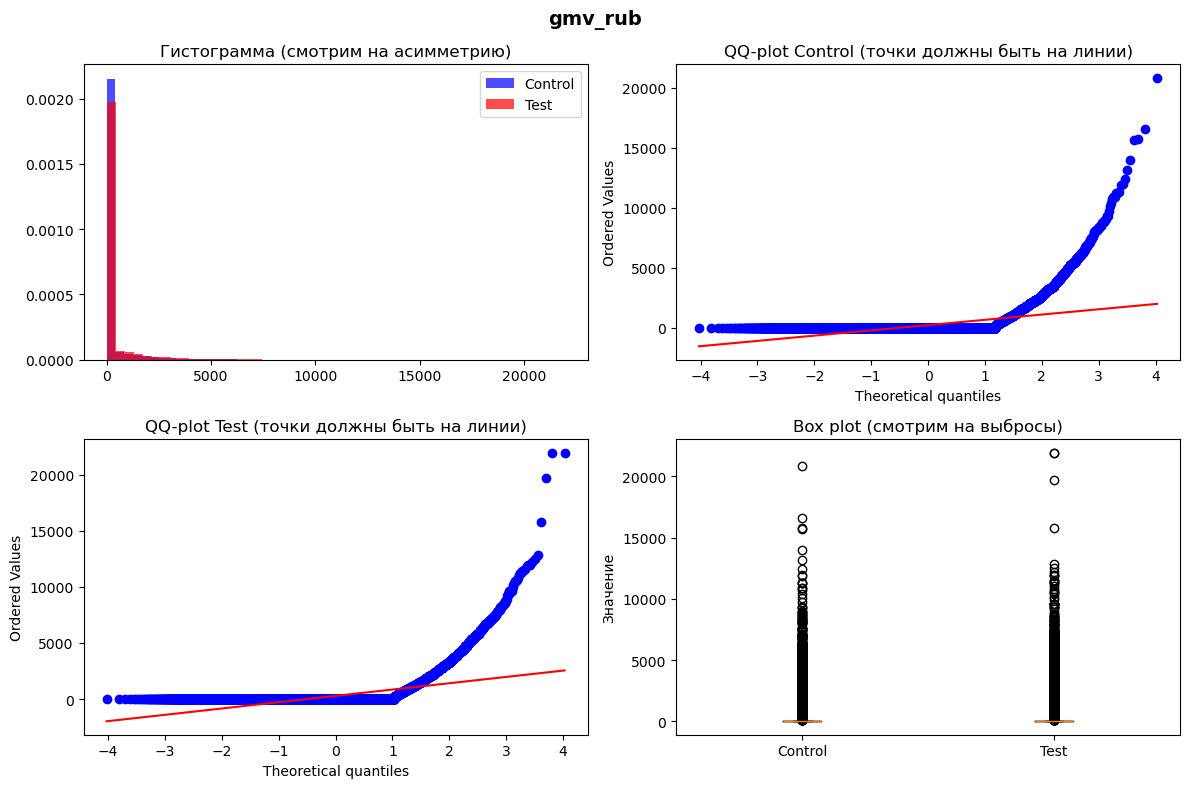


gmv_rub:
  Skewness Control: 6.97
  Skewness Test: 5.98
  Выбросы Control: 245
  Выбросы Test: 249
--------------------------------------------------


C:\Users\Admin\AppData\Local\Temp\ipykernel_23372\1239602954.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 1].boxplot([control_sample, test_sample], labels=['Control', 'Test'])


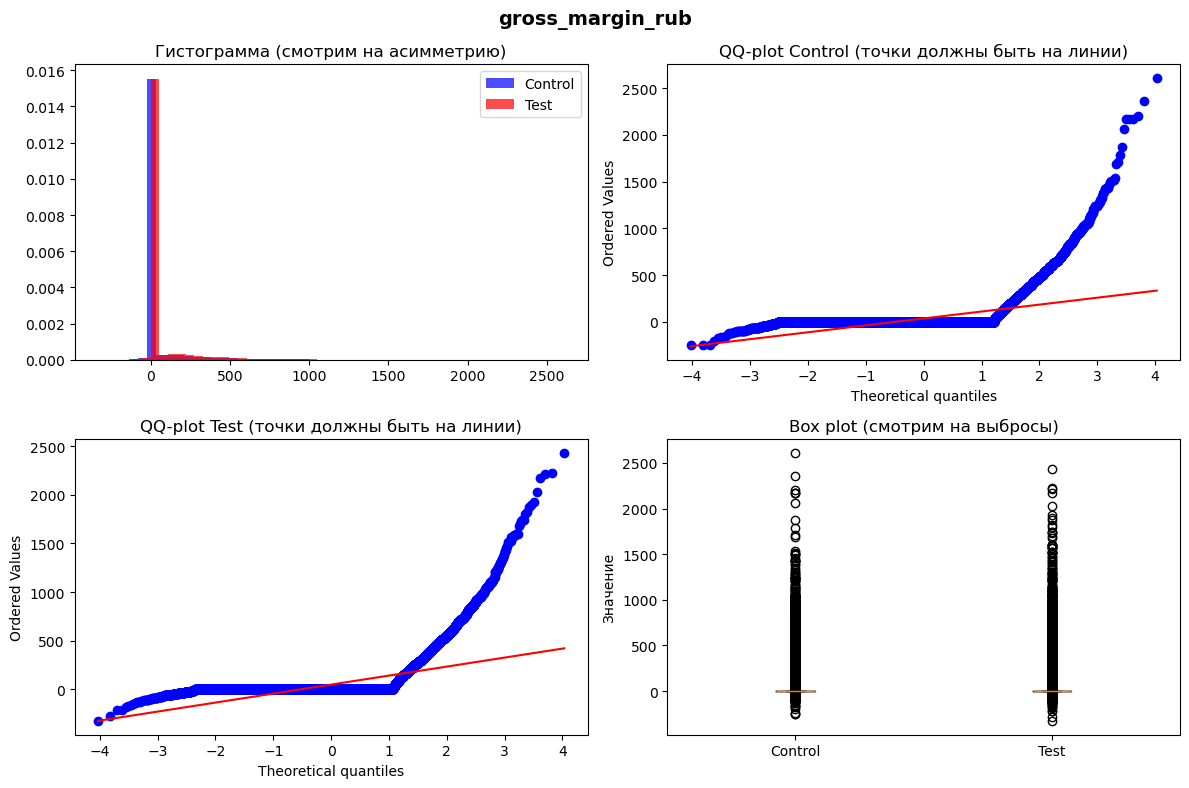


gross_margin_rub:
  Skewness Control: 5.89
  Skewness Test: 4.94
  Выбросы Control: 245
  Выбросы Test: 249
--------------------------------------------------


C:\Users\Admin\AppData\Local\Temp\ipykernel_23372\1239602954.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 1].boxplot([control_sample, test_sample], labels=['Control', 'Test'])


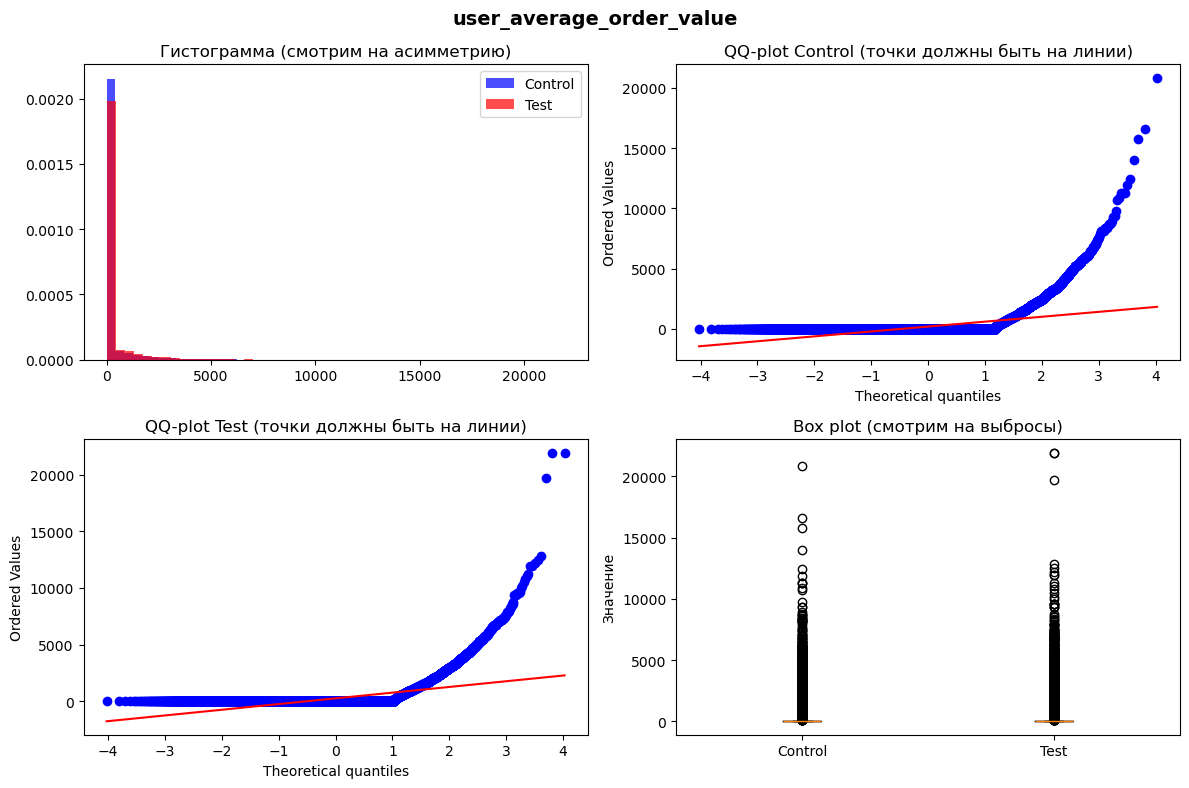


user_average_order_value:
  Skewness Control: 7.07
  Skewness Test: 6.35
  Выбросы Control: 245
  Выбросы Test: 249
--------------------------------------------------


In [120]:
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np
import os

#output_dir = "plots"
#os.makedirs(output_dir, exist_ok=True)

# Создаем фигуру с 4 графиками для каждой метрики
for metric in ["gmv_rub", "gross_margin_rub", "user_average_order_value"]:
    control_sample = control_metrics[metric].dropna()
    test_sample = test_metrics[metric].dropna()
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle(metric, fontsize=14, fontweight='bold')
    
    #Гистограмма - смотрим на форму распределения
    axes[0, 0].hist(control_sample, bins=50, alpha=0.7, color='blue', label='Control', density=True)
    axes[0, 0].hist(test_sample, bins=50, alpha=0.7, color='red', label='Test', density=True)
    axes[0, 0].set_title('Гистограмма (смотрим на асимметрию)')
    axes[0, 0].legend()
    
    #QQ-plot - сравниваем с нормальным распределением
    stats.probplot(control_sample, dist="norm", plot=axes[0, 1])
    stats.probplot(test_sample, dist="norm", plot=axes[1, 0])
    axes[0, 1].set_title('QQ-plot Control (точки должны быть на линии)')
    axes[1, 0].set_title('QQ-plot Test (точки должны быть на линии)')
    
    #Box plot - смотрим на выбросы
    axes[1, 1].boxplot([control_sample, test_sample], labels=['Control', 'Test'])
    axes[1, 1].set_title('Box plot (смотрим на выбросы)')
    axes[1, 1].set_ylabel('Значение')
    
    plt.tight_layout()
    
    
    plt.show()
    
    plt.close(fig)
    
  
    print(f"\n{metric}:")
    print(f"  Skewness Control: {control_sample.skew():.2f}")
    print(f"  Skewness Test: {test_sample.skew():.2f}")
    print(f"  Выбросы Control: {(control_sample > control_sample.quantile(0.99)).sum()}")
    print(f"  Выбросы Test: {(test_sample > test_sample.quantile(0.99)).sum()}")
    print("-" * 50)

> Все три непрерывные метрики (gmv_rub, gross_margin_rub, user_average_order_value) 
> как минимум демонстрируют сильную правостороннюю асимметрию (skewness ~ 6-7), распределение не является нормальным, 
> значит t- или z-тест мы использовать не можем
> 
> но можем использовать непараметрические тесты, мы возьмем Манна - Уитни U
---

#### Та же проверка на нормальность, но более формальня (тест шапиро). 
> Результаты ожидаемые:
> экстремальная ассиметрия + выбросы

In [121]:
from scipy import stats

control_metrics = duckdb.sql("""
    SELECT
        gmv_rub,
        gross_margin_rub,
        user_average_order_value
    FROM ab_user_metrics
    WHERE experiment_group = 'control'
""").df()

test_metrics = duckdb.sql("""
    SELECT
        gmv_rub,
        gross_margin_rub,
        user_average_order_value
    FROM ab_user_metrics
    WHERE experiment_group = 'test'
""").df()

for metric in [
    "gmv_rub",
    "gross_margin_rub",
    "user_average_order_value"
]:

    control_sample = control_metrics[metric].dropna()

    test_sample = test_metrics[metric].dropna()

    print("=" * 70)
    print(metric)

    print(
        "Control skewness:",
        control_sample.skew()
    )

    print(
        "Test skewness:",
        test_sample.skew()
    )

    # Shapiro лучше использовать на случайной подвыборке,
    # а не на десятках тысяч наблюдений
    control_sample_for_test = control_sample.sample(
        min(5000, len(control_sample)),
        random_state=42
    )

    test_sample_for_test = test_sample.sample(
        min(5000, len(test_sample)),
        random_state=42
    )

    control_shapiro = stats.shapiro(
        control_sample_for_test
    )

    test_shapiro = stats.shapiro(
        test_sample_for_test
    )

    print(
        "Control Shapiro p-value:",
        control_shapiro.pvalue
    )

    print(
        "Test Shapiro p-value:",
        test_shapiro.pvalue
    )
    

gmv_rub
Control skewness: 6.974388723665854
Test skewness: 5.9790459738367545
Control Shapiro p-value: 2.8713353065869277e-89
Test Shapiro p-value: 6.519535690144337e-86
gross_margin_rub
Control skewness: 5.894863766827348
Test skewness: 4.94396698795899
Control Shapiro p-value: 8.680022173485964e-89
Test Shapiro p-value: 2.1802770210805284e-85
user_average_order_value
Control skewness: 7.068921999854336
Test skewness: 6.353910444976928
Control Shapiro p-value: 2.4980090569846102e-89
Test Shapiro p-value: 1.0589145908392215e-85


In [122]:
#Учитываем, что GMV per user и Gross margin per user имеют огромное количество нулей 
import pandas as pd
from scipy.stats import mannwhitneyu

ab_user_metrics_df = duckdb.sql("""
    SELECT *
    FROM ab_user_metrics
""").df()

metrics = [
    'gmv_rub',
    'gross_margin_rub',
    'user_average_order_value'
]

results = []

for metric in metrics:

   
    # Для AOV оставляем только пользователей с заказами.
    # Для GMV и Gross Margin оставляем всех пользователей.
 
    if metric == 'user_average_order_value':
        data = ab_user_metrics_df[
            ab_user_metrics_df['orders_count'] > 0
        ].copy()
    else:
        data = ab_user_metrics_df.copy()

    control = data.loc[
        data['experiment_group'] == 'control',
        metric
    ].dropna()

    test = data.loc[
        data['experiment_group'] == 'test',
        metric
    ].dropna()

    # Mann–Whitney U


    u_statistic, p_value = mannwhitneyu(
        control,
        test,
        alternative='two-sided'
    )

    control_mean = control.mean()
    test_mean = test.mean()

    control_median = control.median()
    test_median = test.median()

    # Разница средних


    mean_difference = test_mean - control_mean

    if control_mean != 0:
        mean_difference_percent = (
            test_mean / control_mean - 1
        ) * 100
    else:
        mean_difference_percent = None

    # Разница медиан


    median_difference = (
        test_median - control_median
    )

    if control_median != 0:
        median_difference_percent = (
            test_median / control_median - 1
        ) * 100
    else:
        median_difference_percent = None

    # Positive rate имеет смысл только для GMV и Gross Margin


    if metric in ['gmv_rub', 'gross_margin_rub']:

        control_positive_rate = (
            control > 0
        ).mean() * 100

        test_positive_rate = (
            test > 0
        ).mean() * 100

        positive_rate_difference_pp = (
            test_positive_rate -
            control_positive_rate
        )

    else:

        control_positive_rate = None
        test_positive_rate = None
        positive_rate_difference_pp = None


    results.append({
        'metric': metric,

        'control_n': len(control),
        'test_n': len(test),

        'control_mean': control_mean,
        'test_mean': test_mean,

        'control_median': control_median,
        'test_median': test_median,

        'mean_absolute_difference':
            mean_difference,

        'mean_relative_difference_percent':
            mean_difference_percent,

        'median_absolute_difference':
            median_difference,

        'median_relative_difference_percent':
            median_difference_percent,

        'control_positive_rate_percent':
            control_positive_rate,

        'test_positive_rate_percent':
            test_positive_rate,

        'positive_rate_difference_pp':
            positive_rate_difference_pp,

        'U_statistic':
            u_statistic,

        'p_value':
            p_value,

        'significant_5pct':
            p_value < 0.05
    })


mann_whitney_results = pd.DataFrame(results)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.float_format', '{:.4f}'.format)

print(mann_whitney_results)

                     metric  control_n  test_n  control_mean  test_mean  \
0                   gmv_rub      24473   24828      211.1466   286.4146   
1          gross_margin_rub      24473   24828       35.1141    46.3234   
2  user_average_order_value       2890    3767     1662.7651  1696.1940   

   control_median  test_median  mean_absolute_difference  \
0          0.0000       0.0000                   75.2680   
1          0.0000       0.0000                   11.2093   
2       1157.0000    1224.0000                   33.4290   

   mean_relative_difference_percent  median_absolute_difference  \
0                           35.6473                      0.0000   
1                           31.9225                      0.0000   
2                            2.0104                     67.0000   

   median_relative_difference_percent  control_positive_rate_percent  \
0                                 NaN                        11.8089   
1                                 NaN        

> Медиана GMV в обеих группах равна 0. Это связано с тем,
> что большинство пользователей не совершали покупок.
> 
> Поэтому относительное изменение медианы не рассчитывается:
> изменение 0 -> 0 в процентах математически не определено (NaN).
> Это не связано с пропущенными значениями в исходных данных:
> пропуски GMV были обработаны при формировании пользовательской таблицы,
> а пользователи без покупок получили GMV = 0
>
>Видим, что GMV на пользователя в тестовой группе выше на 35,65%, или на 75,27 р. 
>Одновременно доля пользователей, совершивших покупку, выросла с 11,81% до 15,17% (+3,36 п.п.).
>Различие статистически значимо по критерию Mann–Whitney U (p < 0,001)
>
>Gross margin на пользователя увеличился с 35,11 до 46,32 р, что соответствует росту на 31,92% (+11,21 р). 
>Доля пользователей, принёсших положительную маржу, увеличилась на 3,01 п.п. 
>Различие между группами статистически значимо (Mann–Whitney U, p < 0,001)
>
>В то же время статистически значимого изменения пользовательского среднего чека не обнаружено (Mann–Whitney U, p = 0,110).
>Таким образом, основной эффект эксперимента, вероятно, связан не с увеличением размера заказа, 
>а с увеличением числа пользователей, совершающих покупки

In [123]:
#Формируем пользовательскую таблицу для сегментационного анализа
#из ранее созданной таблицы возьмем нужные данные 
duckdb.sql("""
CREATE OR REPLACE TEMP TABLE segmentation_user_metrics AS

SELECT
    ab_user_metrics.user_id,
    ab_user_metrics.experiment_group,

    users_new.device,
    users_new.region,
    users_new.age_group,
    users_new.traffic_source,

    ab_user_metrics.gmv_rub,
    ab_user_metrics.gross_margin_rub,
    ab_user_metrics.user_average_order_value,

    ab_user_metrics.ctr,
    ab_user_metrics.click_to_order_conversion,

    ab_user_metrics.orders_count,
    ab_user_metrics.impressions_count,
    ab_user_metrics.clicks_count,

    ab_user_metrics.total_session_duration_sec,
    ab_user_metrics.premium_conversion,
    ab_user_metrics.support_contact,
    ab_user_metrics.return_rate

FROM ab_user_metrics

LEFT JOIN users_new 
    ON ab_user_metrics.user_id = users_new.user_id
""")

segmentation_user_metrics = duckdb.sql("""
SELECT *
FROM segmentation_user_metrics
""").df()

print(segmentation_user_metrics.head())
print(segmentation_user_metrics.shape)

    user_id experiment_group   device          region age_group  \
0  u_047970          control      ios           Volga     35-44   
1  u_047983             test  android  Central Russia     35-44   
2  u_048170             test      ios  Central Russia     25-34   
3  u_048192             test  android            Ural     45-54   
4  u_048200             test      ios          Moscow     18-24   

  traffic_source   gmv_rub  gross_margin_rub  user_average_order_value    ctr  \
0        organic    0.0000            0.0000                    0.0000 0.0769   
1           push 2240.0000          575.9000                 2240.0000 0.0455   
2        organic 2029.0000          328.5000                 2029.0000 0.1905   
3      affiliate    0.0000            0.0000                    0.0000 0.1579   
4           push    0.0000            0.0000                    0.0000 0.0500   

   click_to_order_conversion  orders_count  impressions_count  clicks_count  \
0                     0.0000   

In [124]:
segment_columns = [
    'device',
    'region',
    'age_group',
    'traffic_source'
]

for segment_column in segment_columns:

    print("\n" + "=" * 80)
    print(f"Сегментация по: {segment_column}")
    print("=" * 80)

    result = duckdb.sql(f"""
        SELECT
            {segment_column},
            experiment_group,
            COUNT(DISTINCT user_id) AS users
        FROM segmentation_user_metrics
        GROUP BY
            {segment_column},
            experiment_group
        ORDER BY
            {segment_column},
            experiment_group
    """).df()

    print(result)


Сегментация по: device
    device experiment_group  users
0  android          control  14050
1  android             test  14462
2      ios          control   6677
3      ios             test   6608
4      web          control   3746
5      web             test   3758

Сегментация по: region
              region experiment_group  users
0     Central Russia          control   5373
1     Central Russia             test   5426
2           Far East          control    710
3           Far East             test    728
4             Moscow          control   4397
5             Moscow             test   4460
6   Saint Petersburg          control   2118
7   Saint Petersburg             test   2290
8            Siberia          control   2952
9            Siberia             test   2947
10             South          control   2257
11             South             test   2269
12              Ural          control   2499
13              Ural             test   2513
14             Volga          co

In [125]:
segment_results = duckdb.sql("""
WITH segment_metrics AS (

    SELECT
        'device' AS segment_type,
        device AS segment,
        experiment_group,

        COUNT(DISTINCT user_id) AS users,

        AVG(gmv_rub) AS gmv_per_user,

        AVG(gross_margin_rub) AS gross_margin_per_user,

        AVG(ctr) AS ctr,

        AVG(click_to_order_conversion)
            AS click_to_order_conversion,

        AVG(user_average_order_value)
            FILTER (
                WHERE user_average_order_value > 0
            ) AS user_average_order_value

    FROM segmentation_user_metrics

    GROUP BY
        device,
        experiment_group

    UNION ALL

    SELECT
        'region' AS segment_type,
        region AS segment,
        experiment_group,

        COUNT(DISTINCT user_id) AS users,

        AVG(gmv_rub) AS gmv_per_user,

        AVG(gross_margin_rub) AS gross_margin_per_user,

        AVG(ctr) AS ctr,

        AVG(click_to_order_conversion)
            AS click_to_order_conversion,

        AVG(user_average_order_value)
            FILTER (
                WHERE user_average_order_value > 0
            ) AS user_average_order_value

    FROM segmentation_user_metrics

    GROUP BY
        region,
        experiment_group

    UNION ALL

    SELECT
        'age_group' AS segment_type,
        age_group AS segment,
        experiment_group,

        COUNT(DISTINCT user_id) AS users,

        AVG(gmv_rub) AS gmv_per_user,

        AVG(gross_margin_rub) AS gross_margin_per_user,

        AVG(ctr) AS ctr,

        AVG(click_to_order_conversion)
            AS click_to_order_conversion,

        AVG(user_average_order_value)
            FILTER (
                WHERE user_average_order_value > 0
            ) AS user_average_order_value

    FROM segmentation_user_metrics

    GROUP BY
        age_group,
        experiment_group

    UNION ALL

    SELECT
        'traffic_source' AS segment_type,
        traffic_source AS segment,
        experiment_group,

        COUNT(DISTINCT user_id) AS users,

        AVG(gmv_rub) AS gmv_per_user,

        AVG(gross_margin_rub) AS gross_margin_per_user,

        AVG(ctr) AS ctr,

        AVG(click_to_order_conversion)
            AS click_to_order_conversion,

        AVG(user_average_order_value)
            FILTER (
                WHERE user_average_order_value > 0
            ) AS user_average_order_value

    FROM segmentation_user_metrics

    GROUP BY
        traffic_source,
        experiment_group
),

wide_metrics AS (

    SELECT

        segment_type,
        segment,

        MAX(
            CASE
                WHEN experiment_group = 'control'
                THEN users
            END
        ) AS control_users,

        MAX(
            CASE
                WHEN experiment_group = 'test'
                THEN users
            END
        ) AS test_users,

        MAX(
            CASE
                WHEN experiment_group = 'control'
                THEN gmv_per_user
            END
        ) AS control_gmv_per_user,

        MAX(
            CASE
                WHEN experiment_group = 'test'
                THEN gmv_per_user
            END
        ) AS test_gmv_per_user,

        MAX(
            CASE
                WHEN experiment_group = 'control'
                THEN gross_margin_per_user
            END
        ) AS control_gross_margin_per_user,

        MAX(
            CASE
                WHEN experiment_group = 'test'
                THEN gross_margin_per_user
            END
        ) AS test_gross_margin_per_user,

        MAX(
            CASE
                WHEN experiment_group = 'control'
                THEN ctr
            END
        ) AS control_ctr,

        MAX(
            CASE
                WHEN experiment_group = 'test'
                THEN ctr
            END
        ) AS test_ctr,

        MAX(
            CASE
                WHEN experiment_group = 'control'
                THEN user_average_order_value
            END
        ) AS control_user_average_order_value,

        MAX(
            CASE
                WHEN experiment_group = 'test'
                THEN user_average_order_value
            END
        ) AS test_user_average_order_value

    FROM segment_metrics

    GROUP BY
        segment_type,
        segment
)

SELECT

    segment_type,
    segment,

    control_users,
    test_users,

    control_gmv_per_user,
    test_gmv_per_user,

    test_gmv_per_user
        - control_gmv_per_user
        AS gmv_absolute_difference,

    100.0 *
    (
        test_gmv_per_user
        - control_gmv_per_user
    )
    / NULLIF(control_gmv_per_user, 0)
        AS gmv_relative_difference_percent,

    control_gross_margin_per_user,
    test_gross_margin_per_user,

    test_gross_margin_per_user
        - control_gross_margin_per_user
        AS gross_margin_absolute_difference,

    100.0 *
    (
        test_gross_margin_per_user
        - control_gross_margin_per_user
    )
    / NULLIF(control_gross_margin_per_user, 0)
        AS gross_margin_relative_difference_percent,

    control_ctr,
    test_ctr,

    test_ctr - control_ctr
        AS ctr_absolute_difference,

    100.0 *
    (
        test_ctr - control_ctr
    )
    / NULLIF(control_ctr, 0)
        AS ctr_relative_difference_percent,

    control_user_average_order_value,
    test_user_average_order_value,

    test_user_average_order_value
        - control_user_average_order_value
        AS aov_absolute_difference,

    100.0 *
    (
        test_user_average_order_value
        - control_user_average_order_value
    )
    / NULLIF(control_user_average_order_value, 0)
        AS aov_relative_difference_percent

FROM wide_metrics

WHERE
    control_users >= 100
    AND test_users >= 100

ORDER BY
    gmv_relative_difference_percent DESC
""").df()

print(segment_results)

      segment_type           segment  control_users  test_users  \
0           region          Far East            710         728   
1        age_group             45-54           3699        3723   
2           device           android          14050       14462   
3   traffic_source         affiliate           1700        1757   
4           region             Volga           4167        4195   
5   traffic_source              push           2873        2978   
6        age_group             25-34           8250        8273   
7   traffic_source           organic          10372       10477   
8           region           Siberia           2952        2947   
9           region            Moscow           4397        4460   
10          region              Ural           2499        2513   
11  traffic_source            direct           2816        2981   
12          region             South           2257        2269   
13       age_group             35-44           6158        632

> Внутри каждого сегмента проведем статистический анализ 
> чтобы понимать, насколько различия вызваны именно внедрением рекомендательной системы
>
>Поскольку gmv_rub и gross_margin_rub сильно скошены и содержат большое количество нулей, для них логично использовать Mann–Whitney U,
>который мы использовали ранее

In [126]:
segment_columns = [
    'device',
    'region',
    'age_group',
    'traffic_source'
]

metrics = [
    'gmv_rub',
    'gross_margin_rub',
    'user_average_order_value'
]

MIN_USERS_PER_GROUP = 100

segment_test_results = []

for segment_column in segment_columns:

    segments = (
        segmentation_user_metrics[segment_column]
        .dropna()
        .unique()
    )

    for segment_value in segments:

        segment_data = segmentation_user_metrics[
            segmentation_user_metrics[segment_column] == segment_value
        ]

        control = segment_data[
            segment_data['experiment_group'] == 'control'
        ]

        test = segment_data[
            segment_data['experiment_group'] == 'test'
        ]

        if (
            len(control) < MIN_USERS_PER_GROUP
            or len(test) < MIN_USERS_PER_GROUP
        ):
            continue

        for metric in metrics:

            # Для GMV и gross margin включаем всех пользователей,
            # включая пользователей с нулевым значением
            
            # Для AOV анализируем только пользователей,
            # у которых был хотя бы один заказ

            if metric == 'user_average_order_value':

                control_values = control[
                    control[metric] > 0
                ][metric].dropna()

                test_values = test[
                    test[metric] > 0
                ][metric].dropna()

            else:

                control_values = control[metric].dropna()
                test_values = test[metric].dropna()

            if len(control_values) < 2 or len(test_values) < 2:
                continue

            statistic, p_value = mannwhitneyu(
                control_values,
                test_values,
                alternative='two-sided'
            )

            control_mean = control_values.mean()
            test_mean = test_values.mean()

            control_median = control_values.median()
            test_median = test_values.median()

            absolute_difference = (
                test_mean - control_mean
            )

            if control_mean != 0:
                relative_difference_percent = (
                    absolute_difference
                    / control_mean
                    * 100
                )
            else:
                relative_difference_percent = np.nan

            median_absolute_difference = (
                test_median - control_median
            )

            if control_median != 0:
                median_relative_difference_percent = (
                    median_absolute_difference
                    / control_median
                    * 100
                )
            else:
                median_relative_difference_percent = np.nan

            segment_test_results.append({

                'segment_type': segment_column,

                'segment': segment_value,

                'metric': metric,

                'control_n': len(control_values),

                'test_n': len(test_values),

                'control_mean': control_mean,

                'test_mean': test_mean,

                'control_median': control_median,

                'test_median': test_median,

                'absolute_difference':
                    absolute_difference,

                'relative_difference_percent':
                    relative_difference_percent,

                'median_absolute_difference':
                    median_absolute_difference,

                'median_relative_difference_percent':
                    median_relative_difference_percent,

                'U_statistic':
                    statistic,

                'p_value':
                    p_value

            })


segment_test_results = pd.DataFrame(
    segment_test_results
)

print(segment_test_results)

      segment_type   segment                    metric  control_n  test_n  \
0           device       ios                   gmv_rub       6677    6608   
1           device       ios          gross_margin_rub       6677    6608   
2           device       ios  user_average_order_value        782     941   
3           device   android                   gmv_rub      14050   14462   
4           device   android          gross_margin_rub      14050   14462   
..             ...       ...                       ...        ...     ...   
61  traffic_source  paid_ads          gross_margin_rub       4712    4720   
62  traffic_source  paid_ads  user_average_order_value        555     657   
63  traffic_source     email                   gmv_rub       2000    1915   
64  traffic_source     email          gross_margin_rub       2000    1915   
65  traffic_source     email  user_average_order_value        222     263   

    control_mean  test_mean  control_median  test_median  absolute_differen

- Android: GMV вырос на 51.6%, маржа на 43.8% - самый сильный эффект среди всех сегментов
- iOS: GMV вырос на 21.8%, маржа на 17.5%
- Direct трафик: GMV вырос на 39.0%, маржа на 43.1%
- Affiliate трафик: GMV вырос на 47.9%, маржа на 43.1%
> Вывод: тестовая версия значительно увеличила выручку и маржу на всех устройствах
>и для всех источников трафика, где есть достаточный размер выборки
>
>AOV не показал значительных изменений

In [127]:
#У нас много тестов (device × 3 метрики, region × 3 метрики и тд), так что
#если просто использовать p < 0.05, часть значимых результатов может оказаться случайной
#применяем Benjamini–Hochberg
import numpy as np
from statsmodels.stats.multitest import multipletests

segment_test_results['p_value_adjusted'] = np.nan

for metric in metrics:

    mask = (
        segment_test_results['metric'] == metric
    )

    if mask.sum() > 0:

        adjusted = multipletests(
            segment_test_results.loc[mask, 'p_value'],
            alpha=0.05,
            method='fdr_bh'
        )

        segment_test_results.loc[
            mask,
            'p_value_adjusted'
        ] = adjusted[1]

segment_test_results['significant_5pct'] = (
    segment_test_results['p_value_adjusted'] < 0.05
)

print(segment_test_results)

      segment_type   segment                    metric  control_n  test_n  \
0           device       ios                   gmv_rub       6677    6608   
1           device       ios          gross_margin_rub       6677    6608   
2           device       ios  user_average_order_value        782     941   
3           device   android                   gmv_rub      14050   14462   
4           device   android          gross_margin_rub      14050   14462   
..             ...       ...                       ...        ...     ...   
61  traffic_source  paid_ads          gross_margin_rub       4712    4720   
62  traffic_source  paid_ads  user_average_order_value        555     657   
63  traffic_source     email                   gmv_rub       2000    1915   
64  traffic_source     email          gross_margin_rub       2000    1915   
65  traffic_source     email  user_average_order_value        222     263   

    control_mean  test_mean  control_median  test_median  absolute_differen

>Сильных изменений после корректировки не наблюдаем

In [128]:
#Находим наиболее эффективные сегменты
significant_results = segment_test_results[
    segment_test_results['significant_5pct']
].copy()

significant_results = significant_results.sort_values(
    'relative_difference_percent',
    ascending=False
)

print(
    significant_results[
        [
            'segment_type',
            'segment',
            'metric',
            'control_n',
            'test_n',
            'control_mean',
            'test_mean',
            'absolute_difference',
            'relative_difference_percent',
            'p_value',
            'p_value_adjusted',
            'significant_5pct'
        ]
    ]
)

      segment_type           segment            metric  control_n  test_n  \
21          region          Far East           gmv_rub        710     728   
39       age_group             45-54           gmv_rub       3699    3723   
3           device           android           gmv_rub      14050   14462   
54  traffic_source         affiliate           gmv_rub       1700    1757   
4           device           android  gross_margin_rub      14050   14462   
55  traffic_source         affiliate  gross_margin_rub       1700    1757   
9           region             Volga           gmv_rub       4167    4195   
40       age_group             45-54  gross_margin_rub       3699    3723   
51  traffic_source              push           gmv_rub       2873    2978   
36       age_group             25-34           gmv_rub       8250    8273   
48  traffic_source           organic           gmv_rub      10372   10477   
19          region            Moscow  gross_margin_rub       4397    4460   

#### Сегменты с максимальным эффектом:
- География: Дальний Восток (+70.4%), Волга (+42.9%), Сибирь (+38.9%)
- Возраст: 45-54 (+52.8%), 25-34 (+40.4%), 35-44 (+36.4% по марже)
- Устройства: Android (+51.6%), iOS (+21.8%)
- Трафик: Affiliate (+47.9%), Push (+40.9%), Organic (+40.4%)

#### Сегменты с минимальным эффектом
- Email трафик: GMV +5.4% (самый слабый эффект)
- Central Russia: маржа +14.7%
- iOS: маржа +17.5%

#### Итог: тестовая версия наиболее эффективна для:
- Дальневосточного региона
- Пользователей 45-54 лет
- Android устройств
- Affiliate и Push трафика

In [129]:
#Лучшие сегменты именно по GMV
best_gmv_segments = segment_test_results[
    (segment_test_results['metric'] == 'gmv_rub') &
    (segment_test_results['significant_5pct']) &
    (segment_test_results['relative_difference_percent'] > 0)
].sort_values(
    'relative_difference_percent',
    ascending=False
)

print("наиболее эффективные по GMV:")
print(
    best_gmv_segments[
        [
            'segment_type',
            'segment',
            'control_n',
            'test_n',
            'control_mean',
            'test_mean',
            'absolute_difference',
            'relative_difference_percent',
            'p_value',
            'p_value_adjusted'
        ]
    ]
)

наиболее эффективные по GMV:
      segment_type         segment  control_n  test_n  control_mean  \
21          region        Far East        710     728      197.1803   
39       age_group           45-54       3699    3723      183.0295   
3           device         android      14050   14462      202.5308   
54  traffic_source       affiliate       1700    1757      183.5371   
9           region           Volga       4167    4195      196.4694   
51  traffic_source            push       2873    2978      248.8695   
36       age_group           25-34       8250    8273      206.6215   
48  traffic_source         organic      10372   10477      193.2828   
24          region         Siberia       2952    2947      197.2049   
18          region          Moscow       4397    4460      234.6941   
15          region            Ural       2499    2513      220.0400   
57  traffic_source          direct       2816    2981      255.8139   
30          region           South       2257   

In [130]:
#Смотрим где модель действительно ухудшает результат
worst_gmv_segments = segment_test_results[
    (segment_test_results['metric'] == 'gmv_rub') &
    (segment_test_results['significant_5pct']) &
    (segment_test_results['relative_difference_percent'] < 0)
].sort_values(
    'relative_difference_percent',
    ascending=True
)

print("наименее эффективные сегменты по GMV:")
print(
    worst_gmv_segments[
        [
            'segment_type',
            'segment',
            'control_n',
            'test_n',
            'control_mean',
            'test_mean',
            'absolute_difference',
            'relative_difference_percent',
            'p_value',
            'p_value_adjusted'
        ]
    ]
)

наименее эффективные сегменты по GMV:
Empty DataFrame
Columns: [segment_type, segment, control_n, test_n, control_mean, test_mean, absolute_difference, relative_difference_percent, p_value, p_value_adjusted]
Index: []


> Нет отрицательных значений relative_difference_percent среди значимых результатов
> 
> Тестовая модель не ухудшает результаты ни в одном сегменте


In [131]:
gmv_segment_summary = segment_test_results[
    segment_test_results['metric'] == 'gmv_rub'
].copy()

gmv_segment_summary = gmv_segment_summary.sort_values(
    'relative_difference_percent',
    ascending=False
)

print(
    gmv_segment_summary[
        [
            'segment_type',
            'segment',
            'control_n',
            'test_n',
            'control_mean',
            'test_mean',
            'absolute_difference',
            'relative_difference_percent',
            'p_value',
            'p_value_adjusted',
            'significant_5pct'
        ]
    ].to_string(index=False)
)

  segment_type          segment  control_n  test_n  control_mean  test_mean  absolute_difference  relative_difference_percent  p_value  p_value_adjusted  significant_5pct
        region         Far East        710     728      197.1803   336.0522             138.8719                      70.4289   0.0286            0.0315              True
     age_group            45-54       3699    3723      183.0295   279.7397              96.7103                      52.8386   0.0000            0.0000              True
        device          android      14050   14462      202.5308   306.9474             104.4166                      51.5559   0.0000            0.0000              True
traffic_source        affiliate       1700    1757      183.5371   271.3853              87.8483                      47.8640   0.0002            0.0003              True
        region            Volga       4167    4195      196.4694   280.7759              84.3065                      42.9108   0.0001           

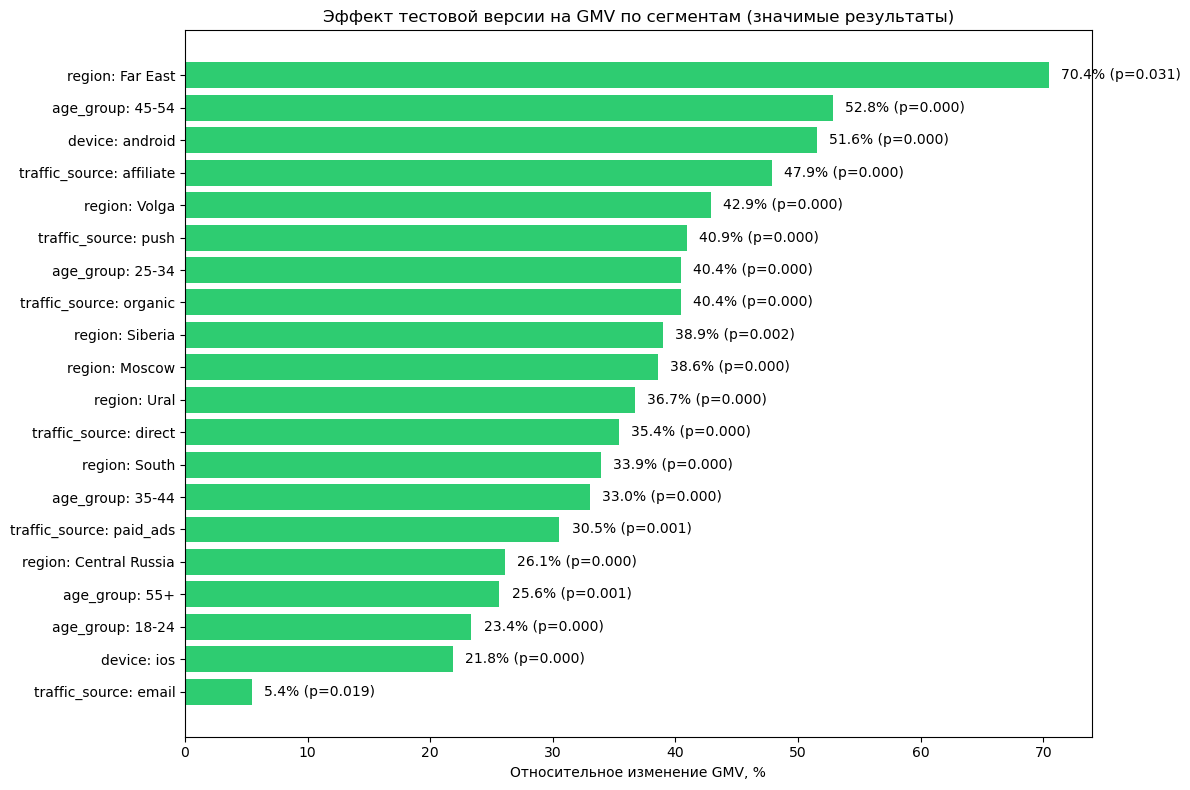

In [132]:
#Для наглядности построим горизонтальный bar chart по GMV и сегментам

import matplotlib.pyplot as plt
import seaborn as sns

#Только значимые сегменты - используем .copy() для создания независимой копии
significant_gmv = gmv_segment_summary[gmv_segment_summary['significant_5pct']].copy()

#подпись для каждого сегмента
significant_gmv.loc[:, 'label'] = significant_gmv['segment_type'] + ': ' + significant_gmv['segment']

#Сортируем по убыванию
significant_gmv = significant_gmv.sort_values('relative_difference_percent')

plt.figure(figsize=(12, 8))
colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in significant_gmv['relative_difference_percent']]
plt.barh(significant_gmv['label'], significant_gmv['relative_difference_percent'], color=colors)
plt.xlabel('Относительное изменение GMV, %')
plt.title('Эффект тестовой версии на GMV по сегментам (значимые результаты)')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)

#Добавляем значения
for i, (value, p_val) in enumerate(zip(significant_gmv['relative_difference_percent'], 
                                         significant_gmv['p_value_adjusted'])):
    plt.text(value + 1, i, f'{value:.1f}% (p={p_val:.3f})', va='center')

plt.tight_layout()
plt.show()

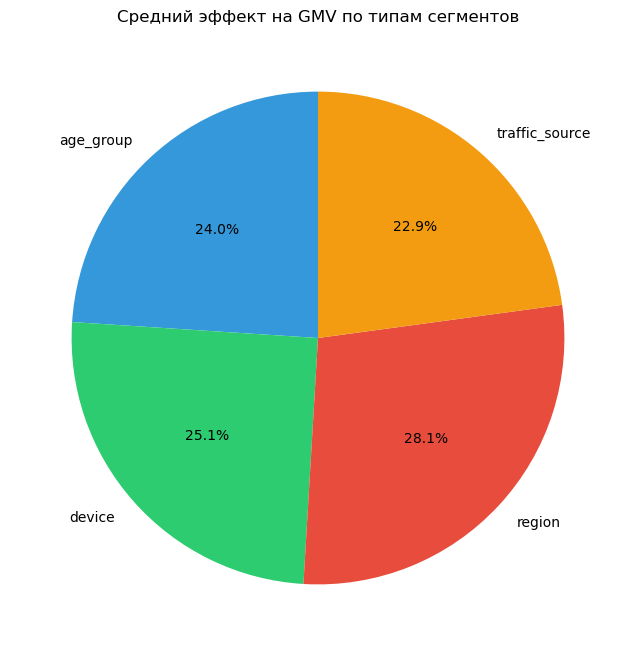

In [133]:
segment_type_effect = significant_gmv.groupby('segment_type')['relative_difference_percent'].mean()

#Pie chart
plt.figure(figsize=(10, 8))
plt.pie(segment_type_effect.values, 
        labels=segment_type_effect.index, 
        autopct='%1.1f%%',
        startangle=90,
        colors=['#3498db', '#2ecc71', '#e74c3c', '#f39c12'])
plt.title('Средний эффект на GMV по типам сегментов')
plt.show()

#### Посмотрим на доверительные интервалы

In [134]:
segment_types = {
    'region': 'region',
    'age_group': 'age_group',
    'device': 'device',
    'traffic_source': 'traffic_source'
}

segment_confidence_results = []

for segment_type, segment_column in segment_types.items():

    segments = duckdb.sql(f"""
        SELECT DISTINCT {segment_column}
        FROM users
        WHERE {segment_column} IS NOT NULL
    """).df()[segment_column].dropna().tolist()

    for segment in segments:

        segment_data = duckdb.sql(f"""
            SELECT
                ab_user_metrics.experiment_group,
                ab_user_metrics.gmv_rub
            FROM ab_user_metrics
            INNER JOIN users
                ON ab_user_metrics.user_id = users.user_id
            WHERE users.{segment_column} = ?
        """, params=[segment]).df()

        control = segment_data.loc[
            segment_data['experiment_group'] == 'control',
            'gmv_rub'
        ].dropna()

        test = segment_data.loc[
            segment_data['experiment_group'] == 'test',
            'gmv_rub'
        ].dropna()

        if len(control) < 30 or len(test) < 30:
            continue

        control_mean = control.mean()
        test_mean = test.mean()

        difference = test_mean - control_mean

        control_standard_error = (
            control.std(ddof=1) / np.sqrt(len(control))
        )

        test_standard_error = (
            test.std(ddof=1) / np.sqrt(len(test))
        )

        standard_error_difference = np.sqrt(
            control_standard_error ** 2 +
            test_standard_error ** 2
        )

        confidence_interval_low = (
            difference - 1.96 * standard_error_difference
        )

        confidence_interval_high = (
            difference + 1.96 * standard_error_difference
        )

        relative_difference = (
            difference / control_mean * 100
            if control_mean != 0
            else np.nan
        )

        segment_confidence_results.append({
            'segment_type': segment_type,
            'segment': segment,
            'control_n': len(control),
            'test_n': len(test),
            'control_mean': control_mean,
            'test_mean': test_mean,
            'absolute_difference': difference,
            'relative_difference_percent': relative_difference,
            'ci_95_low': confidence_interval_low,
            'ci_95_high': confidence_interval_high
        })

segment_confidence_results = pd.DataFrame(
    segment_confidence_results
)

print(segment_confidence_results.sort_values(
    'relative_difference_percent',
    ascending=False
).to_string(index=False))

  segment_type          segment  control_n  test_n  control_mean  test_mean  absolute_difference  relative_difference_percent  ci_95_low  ci_95_high
        region         Far East        710     728      197.1803   336.0522             138.8719                      70.4289    44.5536    233.1902
     age_group            45-54       3699    3723      183.0295   279.7397              96.7103                      52.8386    56.6669    136.7536
        device          android      14050   14462      202.5308   306.9474             104.4166                      51.5559    83.0908    125.7425
traffic_source        affiliate       1700    1757      183.5371   271.3853              87.8483                      47.8640    28.9727    146.7238
        region            Volga       4167    4195      196.4694   280.7759              84.3065                      42.9108    45.8739    122.7391
traffic_source             push       2873    2978      248.8695   350.6840             101.8145          

> Все доверительные интервалы положительные, кроме последних двух сегментов (email и web), 
> где интервалы включают ноль, что говорит о статистической незначимости результатов в этих сегментах

### 5.1 Проверка гетерогенности эффекта (interaction-тест)

#### 5.1.1 Зачем проводим тест

Мы выяснили, что эффект теста **статистически значим** для всей 
аудитории. Но это **не значит**, что он одинаков для всех 
сегментов - например, регионов, возрастных групп или устройств.

Чтобы проверить, **зависит ли эффект от сегмента**, используем 
interaction-тест на основе регрессии.

#### 5.1.2 Модель

Для каждого сегмента строим регрессию:

$$
GMV = \beta_0 + \beta_1 \cdot Test + \beta_2 \cdot Segment 
     + \beta_3 \cdot (Test \times Segment) + \varepsilon
$$

где:
- $Test$ — бинарный флаг (1 = тестовая группа, 0 = контрольная)
- $Segment$ — бинарный флаг сегмента (например, `device = 'web'`)
- $Test \times Segment$ — произведение: интересующий нас член
- $\varepsilon$ — случайная ошибка

#### 5.7.3 Как интерпретировать

| Коэффициент | Что означает |
|---|---|
| $\beta_0$ | Базовый GMV для референсной группы |
| $\beta_1$ | **Основной эффект теста** (для референсного сегмента) |
| $\beta_2$ | Разница в GMV между сегментами в контрольной |
| $\beta_3$ | **Дополнительный эффект теста** в этом сегменте |

**Нас интересует $\beta_3$** - коэффициент при interaction-члене:

- **$\beta_3$ значим (p < 0.05)** → эффект теста **зависит от сегмента**. 
  Сегмент ведёт себя **иначе**, чем референсный.
- **$\beta_3$ не значим (p ≥ 0.05)** → эффект теста **одинаков** 
  во всех сегментах. Различия случайны.

**Пример:**

Если для `device = 'web'` коэффициент $\beta_3 = -92.54$ (p < 0.001), 
это значит:

> Эффект теста для web-пользователей на **92.54 ₽ слабее**, 
> чем для референсной группы (обычно Android).


---

In [135]:
import statsmodels.formula.api as smf

interaction_results = []

for segment_type, segment_column in segment_types.items():

    data = duckdb.sql(f"""
        SELECT
            ab_user_metrics.gmv_rub,
            ab_user_metrics.experiment_group,
            users_new.{segment_column} AS segment
        FROM ab_user_metrics
        INNER JOIN users_new
            ON ab_user_metrics.user_id = users_new.user_id
        WHERE users_new.{segment_column} IS NOT NULL
    """).df()

    data['experiment_group'] = (
        data['experiment_group']
        .astype('category')
    )

    data['segment'] = (
        data['segment']
        .astype('category')
    )

    model = smf.ols(
        'gmv_rub ~ C(experiment_group) * C(segment)',
        data=data
    ).fit()

    interaction_terms = [
        column
        for column in model.params.index
        if 'C(experiment_group)' in column
        and ':' in column
    ]

    for term in interaction_terms:

        interaction_results.append({
            'segment_type': segment_type,
            'interaction': term,
            'coefficient': model.params[term],
            'p_value': model.pvalues[term]
        })

interaction_results = pd.DataFrame(
    interaction_results
)

interaction_results['significant_5pct'] = (
    interaction_results['p_value'] < 0.05
)

print(
    interaction_results.sort_values(
        'p_value'
    ).to_string(index=False)
)

  segment_type                                                interaction  coefficient  p_value  significant_5pct
        device              C(experiment_group)[T.test]:C(segment)[T.web]     -92.5432   0.0001              True
        device              C(experiment_group)[T.test]:C(segment)[T.ios]     -56.2849   0.0034              True
traffic_source            C(experiment_group)[T.test]:C(segment)[T.email]     -75.4120   0.0771             False
        region         C(experiment_group)[T.test]:C(segment)[T.Far East]      84.3825   0.1001             False
     age_group            C(experiment_group)[T.test]:C(segment)[T.45-54]      46.5289   0.1055             False
     age_group            C(experiment_group)[T.test]:C(segment)[T.25-34]      33.3399   0.1656             False
        region           C(experiment_group)[T.test]:C(segment)[T.Moscow]      36.0827   0.1686             False
        region            C(experiment_group)[T.test]:C(segment)[T.Volga]      29.8171  

#### Статистически значимые результаты (p < 0.05):
- Device: Web (коэффициент = -92.54, p = 0.0001) (C(experiment_group)[T.test]:C(segment)[T.web])
- Эффект теста для Web на 92.54 рубля меньше, чем для Android
- Видим, что тест практически не работает на Web (эффект всего +11.88 руб.)
---
- Device: iOS (коэффициент = -56.28, p = 0.0034)
- эффект теста для iOS на 56.28 рубля меньше, чем для Android
- Тест работает на iOS, но слабее (эффект +48.14 руб.)
---
#### Почти статистически значимые результаты  (0.05 < p < 0.11):
- Traffic Source: Email (коэффициент = -75.41, p = 0.0771)
- Тенденция к худшему эффекту для email-трафика
- Не дотягивает до уровня значимости 5%
---
#### Region: Far East (коэффициент = +84.38, p = 0.1001)
- Тенденция к лучшему эффекту для Дальнего Востока
- Может быть случайностью из-за малой выборки
---

#### Сделаем сводку основных метрик и ее визуализацию

In [136]:

business_summary = pd.DataFrame([
    {
        'metric': 'CTR',
        'control': 0.073030,
        'test': 0.090225,
        'relative_effect_percent': 23.546118,
        'p_value': 1.431965e-219
    },
    {
        'metric': 'Click-to-Order Conversion',
        'control': 0.084027,
        'test': 0.091312,
        'relative_effect_percent': 8.669625,
        'p_value': 2.295207e-04
    },
    {
        'metric': 'GMV per user',
        'control': 211.146611,
        'test': 286.414613,
        'relative_effect_percent': 35.647270,
        'p_value': 9.191634e-29
    },
    {
        'metric': 'Gross margin per user',
        'control': 35.114140,
        'test': 46.323435,
        'relative_effect_percent': 31.922452,
        'p_value': 8.802844e-19
    },
    {
        'metric': 'AOV',
        'control': 1662.765052,
        'test': 1696.194032,
        'relative_effect_percent': 2.010445,
        'p_value': 0.109846
    },
    {
        'metric': 'Return Rate',
        'control': 0.055359,
        'test': 0.068246,
        'relative_effect_percent': 23.280062,
        'p_value': 0.024608
    },
    {
        'metric': 'Premium Conversion',
        'control': 0.016671,
        'test': 0.021065,
        'relative_effect_percent': 26.353419,
        'p_value': 3.392140e-04
    },
    {
        'metric': 'Customer Support Rate',
        'control': 0.004822,
        'test': 0.007612,
        'relative_effect_percent': 57.879328,
        'p_value': 8.202628e-05
    }
])

business_summary['significant'] = (
    business_summary['p_value'] < 0.05
)

business_summary

,metric,control,test,relative_effect_percent,p_value,significant
0,CTR,0.0730,0.0902,23.5461,0.0000,True
1,Click-to-Order Conversion,0.0840,0.0913,8.6696,0.0002,True
2,GMV per user,211.1466,286.4146,35.6473,0.0000,True
3,Gross margin per user,35.1141,46.3234,31.9225,0.0000,True
4,AOV,1662.7651,1696.1940,2.0104,0.1098,False
5,Return Rate,0.0554,0.0682,23.2801,0.0246,True
6,Premium Conversion,0.0167,0.0211,26.3534,0.0003,True
7,Customer Support Rate,0.0048,0.0076,57.8793,0.0001,True


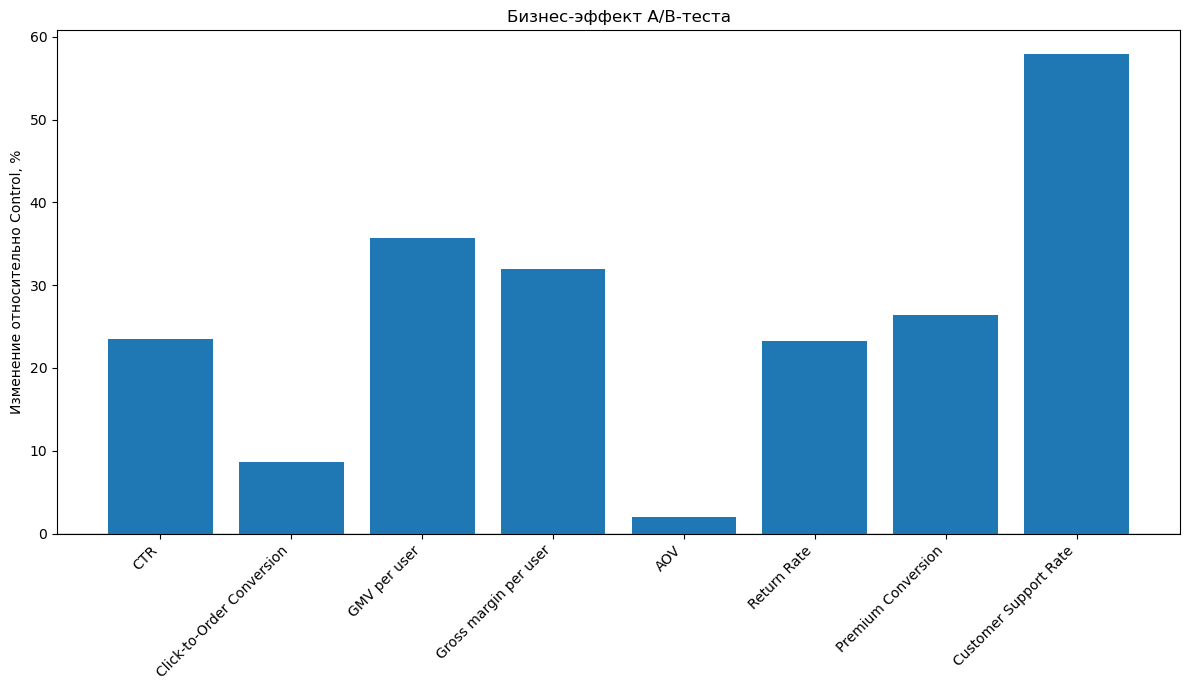

In [137]:
import matplotlib.pyplot as plt

plot_data = business_summary.copy()

plt.figure(figsize=(12, 7))

bars = plt.bar(
    plot_data['metric'],
    plot_data['relative_effect_percent']
)

plt.axhline(
    0,
    linewidth=1
)

plt.ylabel('Изменение относительно Control, %')
plt.title('Бизнес-эффект A/B-теста')

plt.xticks(
    rotation=45,
    ha='right'
)

plt.tight_layout()
plt.show()

### Основной положительный эффект эксперимента связан с ростом коммерческих показателей.

- GMV на пользователя в тестовой группе увеличился с 211,15 до 286,41 руб., то есть на 75,27 руб. или на 35,65%.
> Различие статистически значимо по критерию Mann–Whitney U (p < 0,001).

Это наиболее важный с точки зрения бизнеса результат: 
новая рекомендательная модель не просто увеличивает взаимодействие пользователей с рекламой, но и приводит к дополнительному обороту

- Gross margin на пользователя увеличился с 35,11 до 46,32 руб., то есть на 11,21 руб. или на 31,92%.
> Различие статистически значимо (Mann–Whitney U, p < 0,001)

Важный момент: рост GMV сопровождается сопоставимым ростом валовой маржи.
Следовательно, эффект нельзя объяснить исключительно увеличением оборота
за счёт низкомаржинальных продаж. Новая модель создаёт дополнительную
экономическую ценность для компании.

#### При этом статистически значимого изменения среднего пользовательского чека обнаружено не было:
-  AOV: 1662,77 руб. -> 1696,19 руб.
-  абсолютное изменение: +33,43 руб.
- относительное изменение: +2,01%
-  Mann–Whitney U, p = 0,110.

Следовательно, рост GMV на пользователя в большей степени связан не с тем,
что каждый отдельный заказ стал существенно дороже, а с увеличением числа
пользователей, которые совершают покупки, и/или числа заказов


По сути модель не столько увеличивает размер покупки, сколько расширяет конверсию пользователей в покупателей
Это подтверждается пользовательской воронкой 

#### На этапе "клики -> заказы" тестовая группа показывает улучшение:

- Control: 16,50%
- Test:    19,48%
- Изменение: +2,98 п.п.

 Таким образом, дополнительный трафик, который создаёт рекомендательная модель,
 не полностью теряется после клика: доля пользователей, переходящих к заказу,
 также увеличивается

#### Тем не менее, существенная проблема воронки обнаруживается на этапе "клик -> заказ"

 Control:
- 17 576 кликнувших пользователей
- 2 900 покупателей
- Conversion = 16,50%

 Test:
- 19 354 кликнувших пользователей
- 3 771 покупателей
- Conversion = 19,48%

 Несмотря на улучшение на 2,98 п.п., более 80% пользователей, совершивших клик, всё равно не доходят до покупки.

 Следовательно, дальнейший потенциал роста бизнеса находится не только в улучшении рекомендательной модели, но и в первую очеред в оптимизации данного этапа

#### Наглядный график просадки пользователей, которые не делают заказ после клика

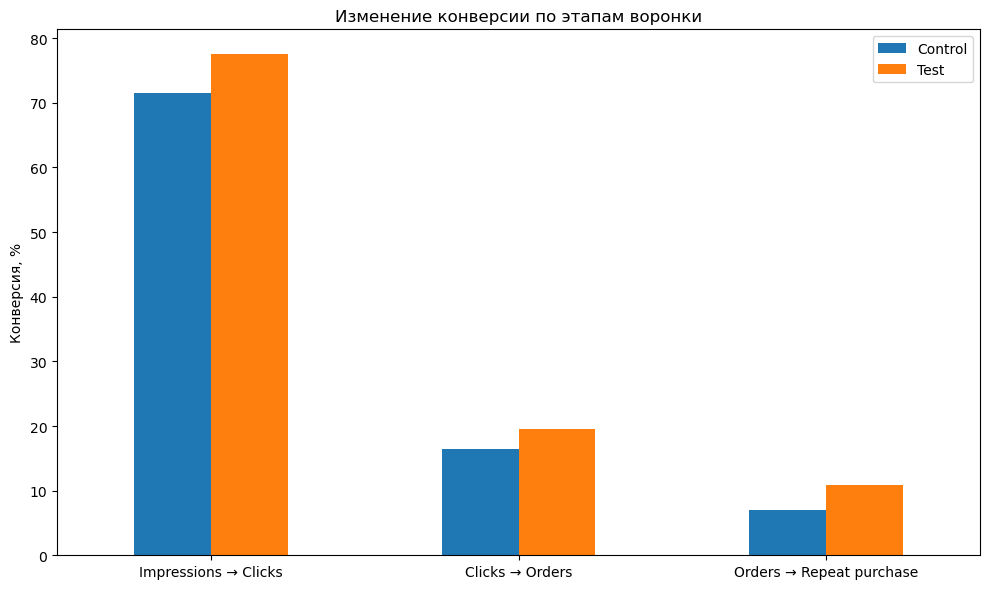

In [138]:

funnel = pd.DataFrame({
    'stage': [
        'Impressions → Clicks',
        'Clicks → Orders',
        'Orders → Repeat purchase'
    ],
    'control': [
        71.46,
        16.50,
        7.03
    ],
    'test': [
        77.50,
        19.48,
        10.95
    ]
})

ax = funnel.set_index('stage')[['control', 'test']].plot(
    kind='bar',
    figsize=(10, 6)
)

ax.set_title('Изменение конверсии по этапам воронки')
ax.set_ylabel('Конверсия, %')
ax.set_xlabel('')
ax.legend(['Control', 'Test'])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#### Основной негативный сигнал связан с возвратами
 Return Rate:

- Control: 5,93%
- Test:    7,58%
- Изменение: +1,65 п.п.
- Относительное ухудшение: +27,8%.

 Это означает, что часть дополнительного спроса может быть менее качественной:
 пользователи чаще совершают покупки, но часть этих покупок впоследствии возвращается.

 Поэтому рост GMV нельзя автоматически интерпретировать как полностью
 дополнительную экономическую ценность

#### Несмотря на рост возвратов, тестовая группа демонстрирует более высокую склонность к повторным покупкам.

Control:
- 204 повторных покупателя из 2900 покупателей = 7,03%

Test:
- 413 повторных покупателей из 3771 покупателей = 10,95%

 >Абсолютный рост: +3,92 п.п.
>
 >Относительный рост: +55,8%.

Это является сильным положительным сигналом:
пользователи тестовой версии не только чаще совершают первую покупку,
но и чаще возвращаются за следующей.

#### При этом идем на компромисс между ростом продаж и качеством пользовательского опыта.

С одной стороны:
- GMV/user +35,65%;
- Gross margin/user +31,92%;
- click -> order +2,98 п.п.;
- повторные покупки +55,8%.

С другой стороны:
- Return Rate +1,65 п.п.;
- Customer Support Rate +57,9%.

Следовательно, новая модель эффективно стимулирует покупки,
однако одновременно увеличивает нагрузку на последующие этапы клиентского пути

#### Отдельно надо сказать, что Customer Support Rate увеличился примерно с 0,48% до 0,76%.
>Относительный рост составляет около 57,9%.

Несмотря на небольшой абсолютный уровень показателя, такой рост требует внимания, поскольку увеличение количества обращений
может частично компенсировать финансовый эффект от дополнительных продаж.

Необходимо проверить:
- какие причины обращений преобладают в test;
- связаны ли обращения с возвратами;
- какие категории товаров генерируют обращения;
- увеличилась ли нагрузка на поддержку пропорционально числу заказов или быстрее него.

#### Эффект новой модели неодинаков для всех сегментов пользователей.

Наиболее сильный эффект наблюдается в следующих сегментах:

- Far East:       +70,43%
- 45-54:          +52,84%
- Android:        +51,56%
- affiliate:      +47,86%
- Volga:          +42,91%
- push:           +40,91%
- 25-34:          +40,42%
- organic:        +40,41%


При этом, основываясь на результатах Interaction test, делаем вывод, что 
единственный значимый фактор, влияющий на эффект теста - тип устройства:
- Android: полный эффект теста (+104.42 руб.)
- iOS: эффект снижен на 56.28 руб. (+48.14 руб. итого)
- Web: эффект снижен на 92.54 руб. (+11.88 руб. итого)
- Для остальных сегментов (регион, возраст, источник трафика) эффект теста статистически одинаковый, при этом 
 нужно дополнительно исследовать email-трафик и Дальний Восток (тенденция к худшему и лучшему трафику соответственно,
но с относительно низким p-value), потому что из-за малой выборки абсолютного числа пользователей
сделанные ранее выводы могут быть некорректными 

 Для принятия решения о персонализации надо как минимум дополнительно проверить размер эффекта и устойчивость результата во времени (
с чем сейчас проблемы из-за временного ограничения в 30 дней)

 При этом уже сейчас можно сделать вывод, что надо внедрять изменение для Android-пользователей, 
адаптировать или доработать AI-систему для iOS и пересмотреть для Web (почти нулевой эффект)

#### Рекомендации руководству 


- Эксперимент дает убедительные основания считать новую AI-модель коммерчески перспективной: GMV на пользователя вырос на 35,65%, 
 gross margin на пользователя - на 31,92%, при этом средний чек статистически значимо не изменился. Это позволяет предположить, 
 что основной механизм эффекта связан с увеличением числа пользователей, совершающих покупки, а не с ростом стоимости отдельного заказа

- Однако полного rollout на данном этапе следует избегать. Одновременно с ростом коммерческих показателей увеличились возвраты
 и обращения в поддержку. Следовательно, необходимо оценить чистый экономический эффект с учетом стоимости возвратов и операционной
 нагрузки.

- Необходимо оптимизировать модель для пользователей IOS и полностью пересмотреть ее для web-пользователей, так как на данный момент
 хорошие результаты наблюдаются только у пользователей Android.

- Рекомендуется поэтапное масштабирование модели с сохранением контрольной группы и мониторингом gross margin как основной бизнес-метрики, 
 а return rate и support contact rate как guardrail-метрик. Перед окончательным масштабированием необходимо дополнительно исследовать 
 неоднородность эффекта по сегментам, причины возвратов, долгосрочный retention и полную unit economics модели.

- Таким образом, текущие результаты являются достаточным основанием для продолжения эксперимента и расширения охвата, но недостаточным
 основанием для безусловного внедрения модели на 100% аудитории.

#### Дополнительные данные, которые можно было бы запросить 

 Для того, чтобы рассчитать реальную добавочную прибыль с учетом возврата:
- стоимость обратной логистики; 
- стоимость обработки возврата;
- стоимость повторной доставки 

 Данные о причинах возвратов (чтобы определить, является ли рост возвратов
следствием самой AI-модели или особенностей конкретных товаров/продавцов): 
- причина возврата;
- категория товара;
- продавец;
- товар;
- стоимость товара;
- связь рекомендации с последующей покупкой и возвратом

 Данные по службе поддержки (оценить реальные расходы на поддержку):
- стоимость одного обращения;
- причины обращения;
- обращения, связанные с рекомендованными товарами;
- время обработки;
- связь обращения с возвратом

 Данные о долгосрочном поведении (метрики минимум за 60–90 дней):
- повторные покупки;
- retention;
- количество заказов;
- cumulative GMV;
- cumulative gross margin;
- возвраты после окончания 30-дневного окна